# Job Scam Detection — Dataset Integration (3-Class, Merged)

This notebook merges the two prior integration notebooks into a single
pipeline. It loads all six original job-posting datasets plus the 3-class
synthetic dataset directly, standardizes their schemas, harmonizes the
target into three classes, and exports one modelling-ready file.


**Target scheme — `is_fraud` has three classes:**

- **0 — Legitimate**
- **1 — Suspicious**
- **2 — Fraudulent / Scam**

**Important, carried over from the original integration notebook:** real
job-board postings (Fuzu, PigiaMe, Corporate Staffing, BrighterMonday,
JobWeb) are **not** automatically labeled legitimate — their `is_fraud`
stays `NaN` unless the project team explicitly approves that labeling
assumption (see the optional, commented-out cell near the end). Only the
Fake Job Postings (EMSCAD) dataset has genuine ground-truth labels among the
real data; those are recovered from its original `fraudulent` column, not
guessed.

**Synthetic data note:** the synthetic file already uses the three-class
scheme (0/1/2) natively — no relabeling is needed for it, only for the
binary EMSCAD labels. Synthetic performance should not be treated as
evidence of real-world model performance; a held-out real, labeled sample
should be used for final evaluation where possible.


This notebook builds the fraud-detection model for job postings — the ML piece that sits alongside the government entity-verification check in our overall system. Goal: given a job posting, output a fraud-risk probability.

In [1]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)


## 1. Load the datasets

All seven source files are loaded directly — no zip step.

In [2]:
# Six original datasets
df_fake = pd.read_csv('fake_job_postings.csv')
df_fuzu = pd.read_csv('fuzu_kenya_jobs.csv')
df_pigia = pd.read_csv('pigiame_jobs_full.csv')
df_corp = pd.read_csv('corporatestaffing_jobs_full.csv')
df_bm = pd.read_csv('brightermonday_kenya_jobs.csv')
df_jobweb = pd.read_csv('jobwebkenya_jobs_full.csv')

# Synthetic dataset -- already uses the 3-class is_fraud scheme (0/1/2)
df_synthetic = pd.read_csv('synthetic_40k.csv')

datasets = {
    'Fake Job Postings': df_fake,
    'Fuzu Kenya': df_fuzu,
    'PigiaMe Kenya': df_pigia,
    'Corporate Staffing Kenya': df_corp,
    'BrighterMonday Kenya': df_bm,
    'JobWeb Kenya': df_jobweb,
    'Synthetic Augmentation': df_synthetic,
}

for name, df in datasets.items():
    print(f'{name}: {df.shape}')


Fake Job Postings: (17880, 18)
Fuzu Kenya: (666, 7)
PigiaMe Kenya: (1500, 8)
Corporate Staffing Kenya: (3988, 7)
BrighterMonday Kenya: (1964, 13)
JobWeb Kenya: (5323, 9)
Synthetic Augmentation: (40000, 13)


## 2. Clean column names

In [3]:
for df in datasets.values():
    df.columns = df.columns.str.strip()

for name, df in datasets.items():
    print(f'\n{name}')
    print(df.columns.tolist())



Fake Job Postings
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Fuzu Kenya
['title', 'company', 'location', 'salary_range', 'tags', 'description', 'source_url']

PigiaMe Kenya
['title', 'company', 'work_type', 'location', 'salary_range', 'posted', 'description', 'source_url']

Corporate Staffing Kenya
['title', 'industry', 'salary_range', 'location', 'deadline', 'description', 'source_url']

BrighterMonday Kenya
['title', 'company', 'category', 'location', 'work_type', 'salary_range', 'min_qualification', 'experience_level', 'experience_length', 'language_requirement', 'working_hours', 'description', 'source_url']

JobWeb Kenya
['title', 'company', 'location', 'state', 'job_type', 'job_category', 'closing_date', 'description', 'source_url']

Synthetic Au

## 3. Standardize each dataset into a common schema

Each source is mapped into the same set of columns. Fields the source
doesn't have are filled with `NaN` rather than guessed.


In [4]:
# 1. Fake Job Postings (EMSCAD) -- has genuine ground-truth labels
df_fake_std = pd.DataFrame({
    'title': df_fake['title'],
    'company': df_fake['company_profile'],
    'location': df_fake['location'],
    'industry_category': df_fake['industry'],
    'work_type': df_fake['employment_type'],
    'salary_range': df_fake['salary_range'],
    'experience_level': df_fake['required_experience'],
    'min_qualification': df_fake['required_education'],
    'description': df_fake['description'],
    'requirements': df_fake['requirements'],
    'source_url': np.nan,
    'source_platform': 'Fake Job Postings Dataset',
    'is_fraud': df_fake['fraudulent'],   # real label, recovered from the original column
    'data_source': 'original',
})

# 2. Fuzu Kenya -- no fraud label available
df_fuzu_std = pd.DataFrame({
    'title': df_fuzu['title'],
    'company': df_fuzu['company'],
    'location': df_fuzu['location'],
    'industry_category': df_fuzu['tags'],
    'work_type': np.nan,
    'salary_range': df_fuzu['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_fuzu['description'],
    'requirements': np.nan,
    'source_url': df_fuzu['source_url'],
    'source_platform': 'Fuzu Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

# 3. PigiaMe Kenya -- no fraud label available
df_pigia_std = pd.DataFrame({
    'title': df_pigia['title'],
    'company': df_pigia['company'],
    'location': df_pigia['location'],
    'industry_category': np.nan,
    'work_type': df_pigia['work_type'],
    'salary_range': df_pigia['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_pigia['description'],
    'requirements': np.nan,
    'source_url': df_pigia['source_url'],
    'source_platform': 'PigiaMe Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

# 4. Corporate Staffing Kenya -- no fraud label available
df_corp_std = pd.DataFrame({
    'title': df_corp['title'],
    'company': np.nan,
    'location': df_corp['location'],
    'industry_category': df_corp['industry'],
    'work_type': np.nan,
    'salary_range': df_corp['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_corp['description'],
    'requirements': np.nan,
    'source_url': df_corp['source_url'],
    'source_platform': 'Corporate Staffing Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})


In [5]:
# 5. BrighterMonday Kenya -- no fraud label available
df_bm_std = pd.DataFrame({
    'title': df_bm['title'],
    'company': df_bm['company'],
    'location': df_bm['location'],
    'industry_category': df_bm['category'],
    'work_type': df_bm['work_type'],
    'salary_range': df_bm['salary_range'],
    'experience_level': df_bm['experience_level'],
    'min_qualification': df_bm['min_qualification'],
    'description': df_bm['description'],
    'requirements': np.nan,
    'source_url': df_bm['source_url'],
    'source_platform': 'BrighterMonday Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})


In [6]:
# 6. JobWeb Kenya -- no fraud label available
df_jobweb_std = pd.DataFrame({
    'title': df_jobweb['title'],
    'company': df_jobweb['company'],
    'location': df_jobweb['location'],
    'industry_category': df_jobweb['job_category'],
    'work_type': df_jobweb['job_type'],
    'salary_range': np.nan,
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_jobweb['description'],
    'requirements': np.nan,
    'source_url': df_jobweb['source_url'],
    'source_platform': 'JobWeb Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})


## 4. Standardize the synthetic dataset

`synthetic_40k.csv` already uses the project's standard column names
directly, and its `is_fraud` column already uses the 0/1/2 scheme — so this
is a straight pass-through with a `data_source` tag added, not a remapping.


In [7]:
df_synthetic_std = pd.DataFrame({
    'title': df_synthetic['title'],
    'company': df_synthetic['company'],
    'location': df_synthetic['location'],
    'industry_category': df_synthetic['industry_category'],
    'work_type': df_synthetic['work_type'],
    'salary_range': df_synthetic['salary_range'],
    'experience_level': df_synthetic['experience_level'],
    'min_qualification': df_synthetic['min_qualification'],
    'description': df_synthetic['description'],
    'requirements': df_synthetic['requirements'],
    'source_url': np.nan,
    'source_platform': 'Synthetic',
    'is_fraud': df_synthetic['is_fraud'],   # already 0 / 1 / 2 -- no remapping needed
    'data_source': 'synthetic',
})


## 5. Combine all datasets

A vertical concatenation — every dataset now shares the same standardized
schema, so we stack rows.


In [8]:
final_df = pd.concat(
    [df_fake_std, df_fuzu_std, df_pigia_std, df_corp_std, df_bm_std, df_jobweb_std, df_synthetic_std],
    ignore_index=True
)

print('Combined shape:', final_df.shape)
final_df.head(3)


Combined shape: (71321, 14)


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,source_url,source_platform,is_fraud,data_source
0,Marketing Intern,"We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, con...","US, NY, New York",NaN,Other,NaN,Internship,NaN,"Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cu...",Experience with content management systems a major plus (any blogging counts!)Familiar with the ...,NaN,Fake Job Postings Dataset,0.0,original
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production Service.90 Seconds is the worlds Cloud Video Produ...","NZ, , Auckland",Marketing and Advertising,Full-time,NaN,Not Applicable,NaN,Organised - Focused - Vibrant - Awesome!Do you have a passion for customer service? Slick typing...,"What we expect from you:Your key responsibility will be to communicate with the client, 90 Secon...",NaN,Fake Job Postings Dataset,0.0,original
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions that meet the needs of companies across the Private ...,"US, IA, Wever",NaN,NaN,NaN,NaN,NaN,"Our client, located in Houston, is actively seeking an experienced Commissioning Machinery Assis...",Implement pre-commissioning and commissioning procedures for rotary equipment.Execute all activi...,NaN,Fake Job Postings Dataset,0.0,original


We combined real labeled fraud data (the EMSCAD dataset) with synthetic Kenya-market postings, since real labeled fraud data alone wasn't enough. Before touching anything else, we carved out 20% of the real labeled postings as a holdout that no model has seen — that's our final source of truth later.

## 6. Harmonize `is_fraud` into three classes

- The **EMSCAD** portion uses a binary scheme where `1` means fraudulent.
  Known fraudulent records are mapped `1 → 2`; known legitimate records stay `0`.
- The **Kenya job-board** portions have no label at all and remain `NaN` —
  not silently assumed legitimate.
- The **synthetic** portion already uses 0/1/2 natively and passes through unchanged.


In [9]:
final_df['is_fraud'] = pd.to_numeric(final_df['is_fraud'], errors='coerce')

# Only the EMSCAD rows are still on the old binary scheme at this point;
# remap just that source so the Kenya-board NaNs and the synthetic 0/1/2
# values are left untouched.
is_emscad = final_df['source_platform'] == 'Fake Job Postings Dataset'
final_df.loc[is_emscad, 'is_fraud'] = final_df.loc[is_emscad, 'is_fraud'].map({0: 0, 1: 2})

class_names = {0: 'Legitimate', 1: 'Suspicious', 2: 'Fraudulent / Scam'}

print('is_fraud value counts after harmonization:')
print(final_df['is_fraud'].value_counts(dropna=False).sort_index())


is_fraud value counts after harmonization:
is_fraud
0.0    39871
1.0    11429
2.0     6580
NaN    13441
Name: count, dtype: int64


## 7. Inspect fraud labels by source

A key sanity check before modelling: confirms the Kenya job-board sources
are still unlabeled (`NaN`), EMSCAD has real 0/2 labels, and the synthetic
data carries all three classes.


In [10]:
fraud_by_source = pd.crosstab(
    final_df['source_platform'],
    final_df['is_fraud'],
    dropna=False
)
display(fraud_by_source)


is_fraud,0.0,1.0,2.0,NaN
source_platform,,,,
BrighterMonday Kenya,0,0,0,1964
Corporate Staffing Kenya,0,0,0,3988
Fake Job Postings Dataset,17014,0,866,0
Fuzu Kenya,0,0,0,666
JobWeb Kenya,0,0,0,5323
PigiaMe Kenya,0,0,0,1500
Synthetic,22857,11429,5714,0


## 8. Optional labeling decision

Left commented out deliberately. Only uncomment this if the project team
explicitly decides to treat unlabeled real job-board postings as
presumed-legitimate (class 0) — this is a labeling **policy** decision, not
a default.


In [11]:
# Example ONLY -- uncomment after the labeling policy has been approved.

# legitimate_platforms = [
#     'Fuzu Kenya',
#     'PigiaMe Kenya',
#     'Corporate Staffing Kenya',
#     'BrighterMonday Kenya',
#     'JobWeb Kenya',
# ]
# final_df.loc[
#     final_df['source_platform'].isin(legitimate_platforms),
#     'is_fraud'
# ] = 0


## 9. Remove exact duplicate postings

In [12]:
before = len(final_df)

final_df = final_df.drop_duplicates(
    subset=['title', 'company', 'location', 'description'],
    keep='first'
).reset_index(drop=True)

after = len(final_df)
print('Rows before duplicate removal:', before)
print('Rows after duplicate removal:', after)
print('Duplicates removed:', before - after)


Rows before duplicate removal: 71321
Rows after duplicate removal: 70302
Duplicates removed: 1019


## 10. Full dataset summary (before trimming metadata columns)

In [13]:
print('Shape:', final_df.shape)

print('\nSource platform distribution:')
display(final_df['source_platform'].value_counts())

print('\nData source distribution:')
display(final_df['data_source'].value_counts())

print('\nFraud label distribution:')
display(final_df['is_fraud'].value_counts(dropna=False).sort_index())

print('\nNamed classes:')
for label, name in class_names.items():
    count = (final_df['is_fraud'] == label).sum()
    print(f'{label}: {name} -> {count:,}')
print(f"NaN / unknown labels -> {final_df['is_fraud'].isna().sum():,}")


Shape: (70302, 14)

Source platform distribution:


source_platform
Synthetic                    39733
Fake Job Postings Dataset    17417
JobWeb Kenya                  5257
Corporate Staffing Kenya      3982
BrighterMonday Kenya          1954
PigiaMe Kenya                 1293
Fuzu Kenya                     666
Name: count, dtype: int64


Data source distribution:


data_source
synthetic    39733
original     30569
Name: count, dtype: int64


Fraud label distribution:


is_fraud
0.0    39219
1.0    11426
2.0     6505
NaN    13152
Name: count, dtype: int64


Named classes:
0: Legitimate -> 39,219
1: Suspicious -> 11,426
2: Fraudulent / Scam -> 6,505
NaN / unknown labels -> 13,152


## 11. Prepare the final modelling export

The following metadata columns are dropped for the modelling-ready file,
matching the original 3-class integration notebook's scope:

- `source_url`
- `source_platform`
- `data_source`

(Section 10 above is where you'd look back if you ever need to know which
row came from where — do that analysis before this step, not after.)


In [14]:
required_columns = [
    'title', 'company', 'location', 'industry_category', 'work_type',
    'salary_range', 'experience_level', 'min_qualification',
    'description', 'requirements', 'is_fraud'
]

model_df = final_df[required_columns].copy()

print('Final columns:')
print(model_df.columns.tolist())

for col in ['source_url', 'source_platform', 'data_source']:
    assert col not in model_df.columns, f'{col} was not removed.'
print('\nMetadata-column check passed.')


Final columns:
['title', 'company', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'is_fraud']

Metadata-column check passed.


## 12. Missing-value overview (modelling columns)

In [15]:
missing_summary = (
    model_df.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .to_frame('missing_percent')
)
display(missing_summary)


,missing_percent
salary_range,31.60
min_qualification,27.58
experience_level,26.10
requirements,22.46
is_fraud,18.71
work_type,14.39
company,12.62
industry_category,8.69
location,6.46
description,1.84


## 13. Preview the final dataset

In [16]:
display(model_df.head())
display(model_df.sample(min(10, len(model_df)), random_state=42))


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud
0,Marketing Intern,"We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, con...","US, NY, New York",NaN,Other,NaN,Internship,NaN,"Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cu...",Experience with content management systems a major plus (any blogging counts!)Familiar with the ...,0.0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production Service.90 Seconds is the worlds Cloud Video Produ...","NZ, , Auckland",Marketing and Advertising,Full-time,NaN,Not Applicable,NaN,Organised - Focused - Vibrant - Awesome!Do you have a passion for customer service? Slick typing...,"What we expect from you:Your key responsibility will be to communicate with the client, 90 Secon...",0.0
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions that meet the needs of companies across the Private ...,"US, IA, Wever",NaN,NaN,NaN,NaN,NaN,"Our client, located in Houston, is actively seeking an experienced Commissioning Machinery Assis...",Implement pre-commissioning and commissioning procedures for rotary equipment.Execute all activi...,0.0
3,Account Executive - Washington DC,Our passion for improving quality of life through geography is at the heart of everything we do....,"US, DC, Washington",Computer Software,Full-time,NaN,Mid-Senior level,Bachelor's Degree,THE COMPANY: ESRI – Environmental Systems Research InstituteOur passion for improving quality of...,"EDUCATION: Bachelor’s or Master’s in GIS, business administration, or a related field, or equiva...",0.0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Capital Management Consulting firm headquartered in M...,"US, FL, Fort Worth",Hospital & Health Care,Full-time,NaN,Mid-Senior level,Bachelor's Degree,"JOB TITLE: Itemization Review ManagerLOCATION: Fort Worth, TX ...","QUALIFICATIONS:RN license in the State of TexasDiploma or Bachelors of Science in Nursing, requi...",0.0


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud
49778,Accounts Assistant,Swift HR Consultants Ltd,Thika,Retail,Full-time,"KES 95,000/month",No experience required,Diploma,Swift HR Consultants Ltd is looking for a Accounts Assistant to work in Thika. Maintain accurate...,Bachelor's degree required. 1-3 years preferred.,1.0
19312,"Programme Officer, BIOPAMA Action Component",NaN,PigiaMe,NaN,Full time,NaN,NaN,NaN,NaN,NaN,NaN
8053,Python Backend Developer,AGOGO creates a personalized audio channel by bringing together your favorite programming -- new...,"US, CA, San Francisco",Computer Software,Full-time,NaN,NaN,NaN,About AGOGOAGOGO is a personalized audio service that brings together your favorite programming ...,"The Ideal CandidateYou have a solid foundation in computer science, algorithms, and software des...",0.0
49928,Administrative Assistant,Jubilee Insurance Group,Kisii,Banking & Finance,Full-time,"KES 98,000/month",No experience required,Certificate,Jubilee Insurance Group is looking for a Administrative Assistant to work in Kisii. Coordinate w...,KCSE certificate required. 1-3 years preferred.,1.0
3186,Social Media Research Analyst,"BaaSSocial Media Marketing with IntelligenceΓια μια ολοκληρωμένη παρουσία στα Social Media, τα β...","GR, I, Athens",Marketing and Advertising,Full-time,NaN,Mid-Senior level,NaN,Key Responsibilities:Social Media Insights Analysis (Monitoring &amp; Reporting)Utilize Social M...,"Qualifications:Proficiency in social media monitoring, analytics and reporting, very high attent...",0.0
13661,PHP Developer,NaN,"CA, BC, Prince Rupert",Human Resources,Full-time,30-50,Mid-Senior level,Unspecified,seeking a strong php developer who is uber up on 5.2 and can handle the following:Let me give yo...,strong background in architecture and development with servers mixed in.,0.0
67001,Driver (Overseas),Vision HR Consultants Ltd,Oman,Hospitality,Full-time,USD 665/month,Entry level,Bachelor's degree,Vision HR Consultants Ltd is looking for a Driver (Overseas) to work in Oman. Assist in the dail...,Certificate required. No experience required preferred.,1.0
34015,Receptionist,Bamburi Cement,Mombasa,Banking & Finance,Full-time,"KES 37,000/month",Entry level,Bachelor's degree,Bamburi Cement is seeking a qualified Receptionist to join our team in Mombasa. Provide excellen...,Diploma required. No experience required preferred.,0.0
41327,Marketing Assistant,Jubilee Insurance,Nairobi,Healthcare,Contract,"KES 54,000/month",1-3 years,Certificate,Jubilee Insurance is seeking a qualified Marketing Assistant to join our team in Nairobi. Collab...,KCSE certificate required. 3-5 years preferred.,0.0
2299,QA Engineer,NaN,NaN,Information Services,Part-time,Oct-15,Associate,Bachelor's Degree,We are looking for a Quality Assurance Engineer to develop and execute exploratory tests as well...,"BS/MS degree in Computer Science, Engineering or a related subject3+ years of experience in soft...",0.0


## 14. Export
next stage : text preprocessing, feature engineering, train/test splitting, and multiclass fraud modelling.


In [17]:
output_file = 'merged_job_scam_3class.csv'
model_df.to_csv(output_file, index=False)
print(f'Saved: {output_file}')


Saved: merged_job_scam_3class.csv


## 15. Data Cleaning - synthetic_40k.csv

In [18]:
df1 = pd.read_csv('synthetic_40k.csv')
df1.shape

(40000, 13)

### 15.1 Initial inspection

In [19]:
print('Shape:', df1.shape)
print()
print(df1.dtypes)
print()
display(df1.head(10))

Shape: (40000, 13)

title                 object
company               object
location              object
industry_category     object
work_type             object
salary_range          object
experience_level      object
min_qualification     object
description           object
requirements          object
source_url           float64
source_platform       object
is_fraud               int64
dtype: object



,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,source_url,source_platform,is_fraud
0,HR Assistant,Vision Manpower Kenya,Kisumu,Insurance,Full-time,"KES 339,000/month",3-5 years,Certificate,"Immediate start, no interview needed! HR Assistant needed in Kisumu. Send KES 3,000 via M-Pesa t...","No qualifications required, immediate hire.",NaN,Synthetic - AjiraCheck,2
1,Receptionist,Naivas Supermarket,Meru,Logistics,Full-time,"KES 35,000/month",Entry level,Certificate,Naivas Supermarket is seeking a qualified Receptionist to join our team in Meru. Collaborate wit...,Certificate required. Entry level preferred.,NaN,Synthetic - AjiraCheck,0
2,Cashier,Naivas Supermarket,Nyeri,Construction,Full-time,"KES 38,000/month",Entry level,Certificate,Naivas Supermarket is seeking a qualified Cashier to join our team in Nyeri. Handle customer inq...,Bachelor's degree required. No experience required preferred.,NaN,Synthetic - AjiraCheck,0
3,Security Guard,Vision HR Consultants Ltd,Qatar,Logistics,Full-time,USD 829/month,1-3 years,Bachelor's degree,Vision HR Consultants Ltd is looking for a Security Guard to work in Qatar. Ensure compliance wi...,Bachelor's degree required. Entry level preferred.,NaN,Synthetic - AjiraCheck,1
4,HR Assistant,Jubilee Insurance,Thika,Logistics,Full-time,"KES 83,000/month",3-5 years,Bachelor's degree,Jubilee Insurance is seeking a qualified HR Assistant to join our team in Thika. Support the tea...,Bachelor's degree required. Entry level preferred.,NaN,Synthetic - AjiraCheck,0
5,Warehouse Supervisor,KenGen,Nairobi,Insurance,Full-time,"KES 43,000/month",Entry level,Diploma,KenGen is seeking a qualified Warehouse Supervisor to join our team in Nairobi. Follow standard ...,KCSE certificate required. 3-5 years preferred.,NaN,Synthetic - AjiraCheck,0
6,Procurement Officer,Equity Bank Kenya,Meru,Retail,Full-time,"KES 48,000/month",1-3 years,Diploma,Equity Bank Kenya is seeking a qualified Procurement Officer to join our team in Meru. Collabora...,Bachelor's degree required. 1-3 years preferred.,NaN,Synthetic - AjiraCheck,0
7,Caregiver,Ready Manpower Limited,Saudi Arabia,Manufacturing,Full-time,USD 741/month,No experience required,Bachelor's degree,Ready Manpower Limited is seeking a qualified Caregiver to join our team in Saudi Arabia. Handle...,KCSE certificate required. Entry level preferred.,NaN,Synthetic - AjiraCheck,0
8,Domestic Worker,Top Level Management Ltd,United Arab Emirates,Telecommunications,Full-time,USD 428/month,3-5 years,KCSE certificate,Top Level Management Ltd is seeking a qualified Domestic Worker to join our team in United Arab ...,Certificate required. 1-3 years preferred.,NaN,Synthetic - AjiraCheck,0
9,Procurement Officer,Prime Manpower Services Ltd,Kisumu,Manufacturing,Contract,"KES 70,000/month",No experience required,KCSE certificate,Prime Manpower Services Ltd is looking for a Procurement Officer to work in Kisumu. Ensure timel...,Bachelor's degree required. 1-3 years preferred.,NaN,Synthetic - AjiraCheck,1


### 15.2 Standardize column names
Removing white space from the header row

In [20]:
df1.columns = df1.columns.str.strip()
print(df1.columns.tolist())

['title', 'company', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'source_url', 'source_platform', 'is_fraud']


### 15.3 Trimming whitespace in text columns

In [21]:
text_cols_df1 = df1.select_dtypes(include='object').columns.tolist()
print('Text columns:', text_cols_df1)

for col in text_cols_df1:
    df1[col] = df1[col].astype('string').str.strip()

# Verify: count of remaining leading/trailing whitespace per column
ws_check = {col: (df1[col] != df1[col].str.strip()).sum() for col in text_cols_df1}
print('Remaining whitespace issues:', ws_check)

Text columns: ['title', 'company', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'source_platform']
Remaining whitespace issues: {'title': np.int64(0), 'company': np.int64(0), 'location': np.int64(0), 'industry_category': np.int64(0), 'work_type': np.int64(0), 'salary_range': np.int64(0), 'experience_level': np.int64(0), 'min_qualification': np.int64(0), 'description': np.int64(0), 'requirements': np.int64(0), 'source_platform': np.int64(0)}


### 15.4 Missing-value audit

"source_url" is 100% null across all 40,000 rows — it carries no information for the dataset, so we drop it rather than leaving it as a column of NaN.

In [22]:
missing_df1 = df1.isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing_df1.to_frame('missing_percent'))

fully_null_cols = missing_df1[missing_df1 == 100].index.tolist()
print('Fully-null columns to drop:', fully_null_cols)

df1 = df1.drop(columns=fully_null_cols)
print('Shape after dropping fully-null columns:', df1.shape)

,missing_percent
source_url,100.0
company,0.0
location,0.0
industry_category,0.0
title,0.0
work_type,0.0
salary_range,0.0
min_qualification,0.0
experience_level,0.0
description,0.0


Fully-null columns to drop: ['source_url']
Shape after dropping fully-null columns: (40000, 12)


### 15.5 Validate and cast "is_fraud"

Confirm the label only ever takes the values `0` (legitimate), `1` (suspicious), `2` (fraudulent) before casting to a small nullable integer type. Anything outside that set gets surfaced.

In [23]:
df1['is_fraud'] = pd.to_numeric(df1['is_fraud'], errors='coerce')

unexpected = df1.loc[~df1['is_fraud'].isin([0, 1, 2]), 'is_fraud']
print('Unexpected / non-numeric is_fraud values:', unexpected.unique())

df1['is_fraud'] = df1['is_fraud'].astype('Int8')
print(df1['is_fraud'].value_counts(dropna=False).sort_index())

Unexpected / non-numeric is_fraud values: []
is_fraud
0    22857
1    11429
2     5714
Name: count, dtype: Int64


### 15.6 Duplicate check

In [24]:
exact_dupes = df1.duplicated().sum()
print('Fully-identical duplicate rows:', exact_dupes)

content_key = ['title', 'company', 'location', 'description']
near_dupes = df1[df1.duplicated(subset=content_key, keep=False)]
print('Rows sharing title+company+location+description (salary differs):', len(near_dupes))

conflict_check = near_dupes.groupby(content_key)['is_fraud'].nunique()
print('Groups with conflicting is_fraud labels:', (conflict_check > 1).sum())

before = len(df1)
df1 = df1.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Rows removed as exact duplicates: {before - len(df1)}')

Fully-identical duplicate rows: 0
Rows sharing title+company+location+description (salary differs): 530
Groups with conflicting is_fraud labels: 0
Rows removed as exact duplicates: 0


No fully-identical rows exist. There ARE 530 rows that share the same "title" / "company" / "location" / "description" but a different "salary_range"so these are kept rather than dropped. 

### 15.7 Parse "salary_range" into numeric fields

"salary_range" is a free-text string like "'KES 339,000/month'" or "'USD 829/month'". For modelling, split it into a "salary_currency", "salary_amount" (numeric), and "salary_period", then add a "salary_amount_kes" column normalized to Kenyan shillings so USD and KES postings are comparable.

**Assumption made explicit:** a fixed FX rate of 1 USD = 130 KES is used for the conversion. Adjust "USD_TO_KES" below if a different rate is preferred — it's isolated in one place on purpose.

In [25]:
import re

USD_TO_KES = 130  # <- adjust this single constant if a different FX rate is needed

salary_pattern = re.compile(r'^(KES|USD)\s*([\d,]+)\s*/\s*(\w+)$', flags=re.IGNORECASE)

def parse_salary(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])
    m = salary_pattern.match(str(value).strip())
    if not m:
        return pd.Series([np.nan, np.nan, np.nan])
    currency, amount, period = m.groups()
    return pd.Series([currency.upper(), float(amount.replace(',', '')), period.lower()])

df1[['salary_currency', 'salary_amount', 'salary_period']] = df1['salary_range'].apply(parse_salary)

unparsed = df1['salary_range'].notna() & df1['salary_currency'].isna()
print('salary_range values that failed to parse:', unparsed.sum())
if unparsed.sum():
    display(df1.loc[unparsed, 'salary_range'].unique()[:10])

df1['salary_amount_kes'] = np.where(
    df1['salary_currency'] == 'USD',
    df1['salary_amount'] * USD_TO_KES,
    df1['salary_amount']
)

print(df1[['salary_range', 'salary_currency', 'salary_amount', 'salary_period', 'salary_amount_kes']].head())

salary_range values that failed to parse: 0
        salary_range salary_currency  salary_amount salary_period  \
0  KES 339,000/month             KES       339000.0         month   
1   KES 35,000/month             KES        35000.0         month   
2   KES 38,000/month             KES        38000.0         month   
3      USD 829/month             USD          829.0         month   
4   KES 83,000/month             KES        83000.0         month   

   salary_amount_kes  
0           339000.0  
1            35000.0  
2            38000.0  
3           107770.0  
4            83000.0  


### 15.8 Validate categorical fields

Full value set for each categorical column so any typo, stray category, or unexpected value is caught before modelling.

In [26]:
categorical_cols_df1 = ['work_type', 'experience_level', 'min_qualification', 'industry_category']

for col in categorical_cols_df1:
    print(f'{col} ({df1[col].nunique()} unique values)')
    print(df1[col].value_counts(dropna=False))
    print()

work_type (2 unique values)
work_type
Full-time    30028
Contract      9972
Name: count, dtype: Int64

experience_level (4 unique values)
experience_level
No experience required    10104
3-5 years                  9981
Entry level                9977
1-3 years                  9938
Name: count, dtype: Int64

min_qualification (4 unique values)
min_qualification
KCSE certificate     10140
Diploma              10024
Certificate           9960
Bachelor's degree     9876
Name: count, dtype: Int64

industry_category (9 unique values)
industry_category
Healthcare            4499
Manufacturing         4496
Retail                4475
Telecommunications    4465
Hospitality           4464
Banking & Finance     4439
Logistics             4425
Insurance             4371
Construction          4366
Name: count, dtype: Int64



### 15.9 Final check and export

In [27]:
print('Final shape:', df1.shape)
print()
print('Remaining missing values:')
display(df1.isna().sum().to_frame('missing_count'))

df1.to_csv('synthetic_40k_clean.csv', index=False)
print("\nSaved: synthetic_40k_clean.csv")
df1.duplicated().sum()

Final shape: (40000, 16)

Remaining missing values:


,missing_count
title,0
company,0
location,0
industry_category,0
work_type,0
salary_range,0
experience_level,0
min_qualification,0
description,0
requirements,0



Saved: synthetic_40k_clean.csv


np.int64(0)

## 16. Data cleaning — synthetic_augmentation_postings.csv (df2)

In [28]:
df2 = pd.read_csv('synthetic_augmentation_postings.csv')
print('Shape:', df2.shape)
print()
print(df2.dtypes)
print()
display(df2.head(3))

Shape: (5000, 14)

posting_id          object
title               object
description         object
company             object
agency             float64
location            object
salary             float64
employment_type     object
email               object
source             float64
country             object
is_overseas         object
is_fraud             int64
data_source         object
dtype: object



,posting_id,title,description,company,agency,location,salary,employment_type,email,source,country,is_overseas,is_fraud,data_source
0,SYN-000000,Customer Service Agent,Salary is commensurate with experience and will be discussed during the interview process. No fe...,"Williams, Nicholson and Davis",NaN,Machakos,NaN,Full-time,browningjason@hamilton.com,NaN,Kenya,No,0,synthetic_augmentation
1,SYN-000001,Data Entry Clerk,We are looking for a Data Entry Clerk to join our team based in Kakamega. The successful candida...,"Martinez, Walker and Burton",NaN,Kakamega,NaN,Part-time,rayrandy@williams.com,NaN,Kenya,No,0,synthetic_augmentation
2,SYN-000002,Sales Representative,Minimum requirements: a diploma or degree in a relevant field and at least 1 years of experience...,"Parker, Cabrera and White",NaN,Kakamega,NaN,Full-time,nathankelley@elliott.com,NaN,Kenya,No,0,synthetic_augmentation


### 16.1 Standardize column names and trim text fields

In [29]:
df2.columns = df2.columns.str.strip()

text_cols_df2 = df2.select_dtypes(include='object').columns.tolist()
print('Text columns:', text_cols_df2)

for col in text_cols_df2:
    df2[col] = df2[col].astype('string').str.strip()

Text columns: ['posting_id', 'title', 'description', 'company', 'location', 'employment_type', 'email', 'country', 'is_overseas', 'data_source']


### 16.2 Missing-value

In [30]:
missing_df2 = df2.isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing_df2.to_frame('missing_percent'))

fully_null_cols_df2 = missing_df2[missing_df2 == 100].index.tolist()
print('Fully-null columns to drop:', fully_null_cols_df2)
df2 = df2.drop(columns=fully_null_cols_df2)

df2['has_email'] = df2['email'].notna()
df2['email'] = df2['email'].fillna('not_provided')

print('\nShape after cleanup:', df2.shape)
print(df2['has_email'].value_counts())

,missing_percent
agency,100.00
salary,100.00
source,100.00
email,14.84
title,0.00
posting_id,0.00
location,0.00
company,0.00
description,0.00
employment_type,0.00


Fully-null columns to drop: ['agency', 'salary', 'source']

Shape after cleanup: (5000, 12)
has_email
True     4258
False     742
Name: count, dtype: int64


"agency", "salary", and "source" are 100% null across all 5,000 rows and so we drop them.

"email" is missing for ~15% of rows. Rather than dropping those rows, a "has_email" flag is kept and the NaNs are filled with an explicit placeholder instead of silently left blank.

### 16.3 Validate email format
Sanity-check every non-placeholder email against a basic "local@domain.tld" pattern and flag anything that doesn't match instead of assuming the column is clean.

In [31]:
email_pattern = re.compile(r'^[^@\s]+@[^@\s]+\.[^@\s]+$')

real_emails = df2.loc[df2['has_email'], 'email']
invalid_emails = real_emails[~real_emails.str.match(email_pattern)]
print(f'Invalid email formats: {len(invalid_emails)} out of {len(real_emails)}')
if len(invalid_emails):
    display(invalid_emails.head(10))

Invalid email formats: 0 out of 4258


### 16.4 Validate and cast 'is_fraud'

In [32]:
df2['is_fraud'] = pd.to_numeric(df2['is_fraud'], errors='coerce')

unexpected_df2 = df2.loc[~df2['is_fraud'].isin([0, 1, 2]), 'is_fraud']
print('Unexpected / non-numeric is_fraud values:', unexpected_df2.unique())

df2['is_fraud'] = df2['is_fraud'].astype('Int8')
print(df2['is_fraud'].value_counts(dropna=False).sort_index())

Unexpected / non-numeric is_fraud values: []
is_fraud
0    4258
1     535
2     207
Name: count, dtype: Int64


### 16.5 Check zero-variance columns

"country" ("'Kenya'") and "is_overseas" ("'No'") are constant across every row in this file. They're kept rather than dropped — they carry no information *within* this file alone, but they matter once this dataset is combined with sources that do vary on those fields — but it's worth flagging explicitly so it isn't mistaken for a bug later.

In [33]:
for col in ['country', 'is_overseas']:
    print(f'{col}: {df2[col].nunique()} unique value(s) -> {df2[col].unique()}')

country: 1 unique value(s) -> <StringArray>
['Kenya']
Length: 1, dtype: string
is_overseas: 1 unique value(s) -> <StringArray>
['No']
Length: 1, dtype: string


### 16.6 Remove duplicate postings

"posting_id" is unique for every row. Checking on "title" / "company" / "location" / "description" instead finds 10 pairs (20 rows) that are genuinely identical postings — same text, same employer, same location, same label — just issued a different ID. Those are true duplicates and are dropped, keeping the first occurrence.

In [34]:
content_key_df2 = ['title', 'company', 'location', 'description']

dupe_mask = df2.duplicated(subset=content_key_df2, keep=False)
print('Rows involved in content duplicates:', dupe_mask.sum())
display(df2.loc[dupe_mask, ['posting_id'] + content_key_df2 + ['is_fraud']].sort_values(content_key_df2))
before_df2 = len(df2)
df2 = df2.drop_duplicates(subset=content_key_df2, keep='first').reset_index(drop=True)
print(f'\nRows removed as duplicate postings: {before_df2 - len(df2)}')

Rows involved in content duplicates: 20


,posting_id,title,company,location,description,is_fraud
2055,SYN-002055,Administrative Assistant,Not disclosed,Eldoret,We are looking for a Administrative Assistant to join our team based in Eldoret. The successful ...,1
4341,SYN-004341,Administrative Assistant,Not disclosed,Eldoret,We are looking for a Administrative Assistant to join our team based in Eldoret. The successful ...,1
2226,SYN-002226,Administrative Assistant,Not disclosed,Kakamega,We are looking for a Administrative Assistant to join our team based in Kakamega. The successful...,1
2257,SYN-002257,Administrative Assistant,Not disclosed,Kakamega,We are looking for a Administrative Assistant to join our team based in Kakamega. The successful...,1
4663,SYN-004663,Administrative Assistant,Not disclosed,Kisumu,Salary is commensurate with experience and will be discussed during the interview process. No fe...,1
4769,SYN-004769,Administrative Assistant,Not disclosed,Kisumu,Salary is commensurate with experience and will be discussed during the interview process. No fe...,1
1931,SYN-001931,Delivery Driver,Not disclosed,Kakamega,We are looking for a Delivery Driver to join our team based in Kakamega. The successful candidat...,1
4717,SYN-004717,Delivery Driver,Not disclosed,Kakamega,We are looking for a Delivery Driver to join our team based in Kakamega. The successful candidat...,1
948,SYN-000948,Delivery Driver,Not disclosed,Kisumu,We are looking for a Delivery Driver to join our team based in Kisumu. The successful candidate ...,1
2449,SYN-002449,Delivery Driver,Not disclosed,Kisumu,We are looking for a Delivery Driver to join our team based in Kisumu. The successful candidate ...,1



Rows removed as duplicate postings: 10


### 16.7 Final check and export

In [35]:
print('Final shape:', df2.shape)
print()
print('Remaining missing values:')
display(df2.isna().sum().to_frame('missing_count'))

df2.to_csv('synthetic_augmentation_postings_clean.csv', index=False)
print("\nSaved: synthetic_augmentation_postings_clean.csv")
df2.duplicated().sum()

Final shape: (4990, 12)

Remaining missing values:


,missing_count
posting_id,0
title,0
description,0
company,0
location,0
employment_type,0
email,0
country,0
is_overseas,0
is_fraud,0



Saved: synthetic_augmentation_postings_clean.csv


np.int64(0)

## 17. EXPLORATORY DATA ANALYSIS (EDA)

In This section, we explore the cleaned data and craete visuals to be able to understand our data much better, find simple patterns before feature selection and modelling.

In [36]:
import matplotlib.pyplot as plt

### 17.1 Look at the final dataset

In [37]:
print('Rows:', len(model_df))
print('Columns:', len(model_df.columns))

print('\nColumn types:')
display(model_df.dtypes)

print('\nFirst 5 rows:')
display(model_df.head())

Rows: 70302
Columns: 11

Column types:


title                 object
company               object
location              object
industry_category     object
work_type             object
salary_range          object
experience_level      object
min_qualification     object
description           object
requirements          object
is_fraud             float64
dtype: object


First 5 rows:


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud
0,Marketing Intern,"We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, con...","US, NY, New York",NaN,Other,NaN,Internship,NaN,"Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cu...",Experience with content management systems a major plus (any blogging counts!)Familiar with the ...,0.0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production Service.90 Seconds is the worlds Cloud Video Produ...","NZ, , Auckland",Marketing and Advertising,Full-time,NaN,Not Applicable,NaN,Organised - Focused - Vibrant - Awesome!Do you have a passion for customer service? Slick typing...,"What we expect from you:Your key responsibility will be to communicate with the client, 90 Secon...",0.0
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions that meet the needs of companies across the Private ...,"US, IA, Wever",NaN,NaN,NaN,NaN,NaN,"Our client, located in Houston, is actively seeking an experienced Commissioning Machinery Assis...",Implement pre-commissioning and commissioning procedures for rotary equipment.Execute all activi...,0.0
3,Account Executive - Washington DC,Our passion for improving quality of life through geography is at the heart of everything we do....,"US, DC, Washington",Computer Software,Full-time,NaN,Mid-Senior level,Bachelor's Degree,THE COMPANY: ESRI – Environmental Systems Research InstituteOur passion for improving quality of...,"EDUCATION: Bachelor’s or Master’s in GIS, business administration, or a related field, or equiva...",0.0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Capital Management Consulting firm headquartered in M...,"US, FL, Fort Worth",Hospital & Health Care,Full-time,NaN,Mid-Senior level,Bachelor's Degree,"JOB TITLE: Itemization Review ManagerLOCATION: Fort Worth, TX ...","QUALIFICATIONS:RN license in the State of TexasDiploma or Bachelors of Science in Nursing, requi...",0.0


### 17.2 Fraud class distribution

Only rows with a known fraud label are used here.

is_fraud
Legitimate    39219
Suspicious    11426
Fraudulent     6505
Name: count, dtype: int64


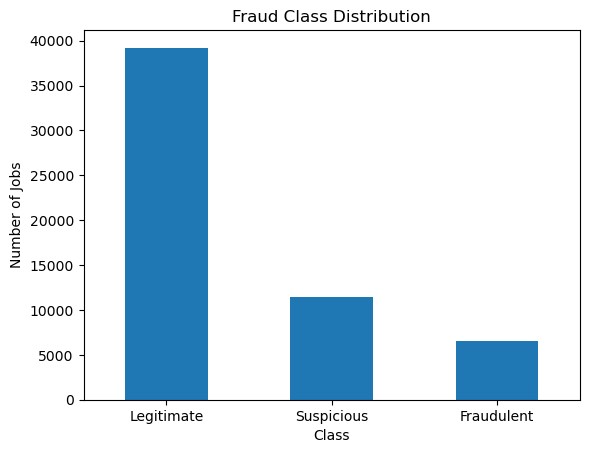

In [38]:
labeled_df = model_df[model_df['is_fraud'].notna()]

class_counts = labeled_df['is_fraud'].value_counts().sort_index()
class_counts.index = class_counts.index.map({
    0: 'Legitimate',
    1: 'Suspicious',
    2: 'Fraudulent'
})

print(class_counts)

class_counts.plot(kind='bar')
plt.title('Fraud Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()

### 17.3 Labeled and unlabeled records

is_fraud
Labeled      57150
Unlabeled    13152
Name: count, dtype: int64


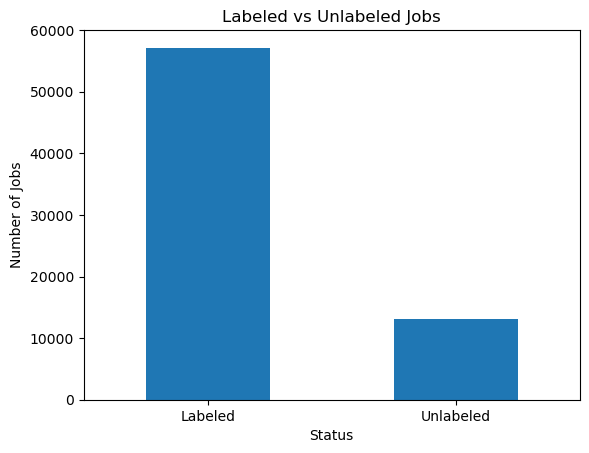

In [39]:
label_status = model_df['is_fraud'].isna().map({
    True: 'Unlabeled',
    False: 'Labeled'
}).value_counts()

print(label_status)

label_status.plot(kind='bar')
plt.title('Labeled vs Unlabeled Jobs')
plt.xlabel('Status')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()

### 17.4 Fraud labels by source

This shows which sources contain labels and which are unlabeled.

In [40]:
source_labels = pd.crosstab(
    final_df['source_platform'],
    final_df['is_fraud'],
    dropna=False
)

print(source_labels)

is_fraud                     0.0    1.0   2.0   NaN
source_platform                                    
BrighterMonday Kenya           0      0     0  1954
Corporate Staffing Kenya       0      0     0  3982
Fake Job Postings Dataset  16565      0   852     0
Fuzu Kenya                     0      0     0   666
JobWeb Kenya                   0      0     0  5257
PigiaMe Kenya                  0      0     0  1293
Synthetic                  22654  11426  5653     0


### 17.5 Missing values

In [41]:
missing = model_df.isna().sum().sort_values(ascending=False)
print(missing)

salary_range         22216
min_qualification    19388
experience_level     18350
requirements         15790
is_fraud             13152
work_type            10115
company               8875
industry_category     6108
location              4539
description           1296
title                    1
dtype: int64


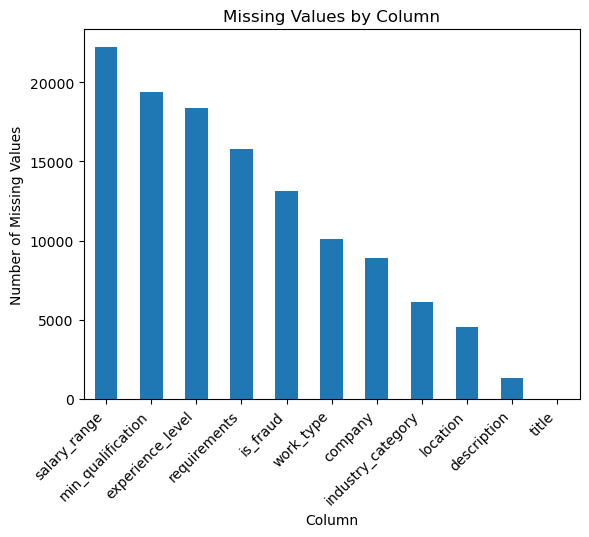

In [42]:
missing[missing > 0].plot(kind='bar')
plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.show()

### 17.6 Work type

work_type
Full-time     41112
Contract      11604
Missing       10115
Full-Time      4914
Full time      1115
Part-time       754
Temporary       234
Other           223
Internship      218
Part time        10
Part-Time         3
Name: count, dtype: int64


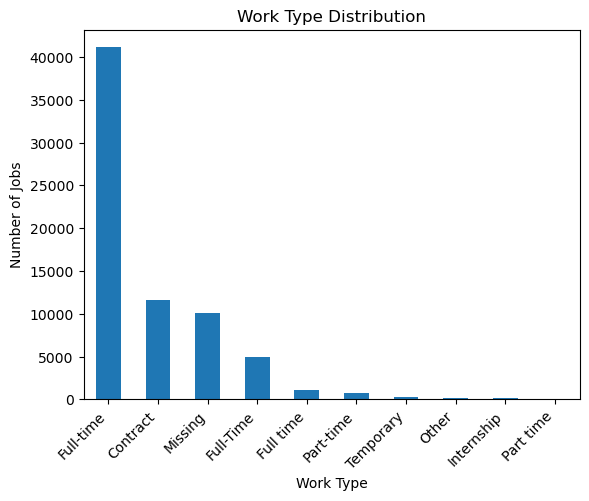

In [43]:
work_type = model_df['work_type'].fillna('Missing').value_counts()
print(work_type)

work_type.head(10).plot(kind='bar')
plt.title('Work Type Distribution')
plt.xlabel('Work Type')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.show()

### 17.7 Experience level

experience_level
Missing                   18350
Entry level               13017
No experience required    10029
3-5 years                  9925
1-3 years                  9874
Mid-Senior level           3741
Associate                  2231
Not Applicable             1058
Mid level                   922
Director                    381
Internship                  370
Senior level                179
Executive                   138
Internship & Graduate        50
Executive level              25
No Experience                12
Name: count, dtype: int64


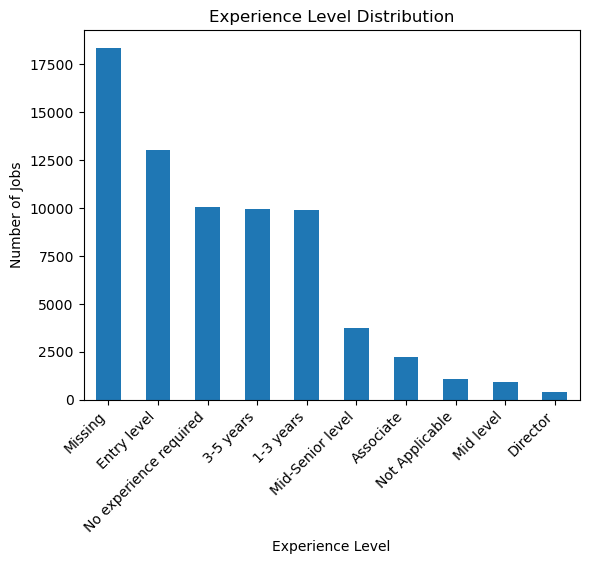

In [44]:
experience = model_df['experience_level'].fillna('Missing').value_counts()
print(experience)

experience.head(10).plot(kind='bar')
plt.title('Experience Level Distribution')
plt.xlabel('Experience Level')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.show()

### 17.8 Industry category

industry_category
Missing                                6108
Telecommunications                     4732
Retail                                 4670
Hospitality                            4512
Construction                           4498
Manufacturing                          4474
Healthcare                             4471
Insurance                              4459
Banking & Finance                      4401
Logistics                              4397
Information Technology and Services    1693
Computer Software                      1351
Internet                               1049
Education Management                    817
Marketing and Advertising               812
Name: count, dtype: int64


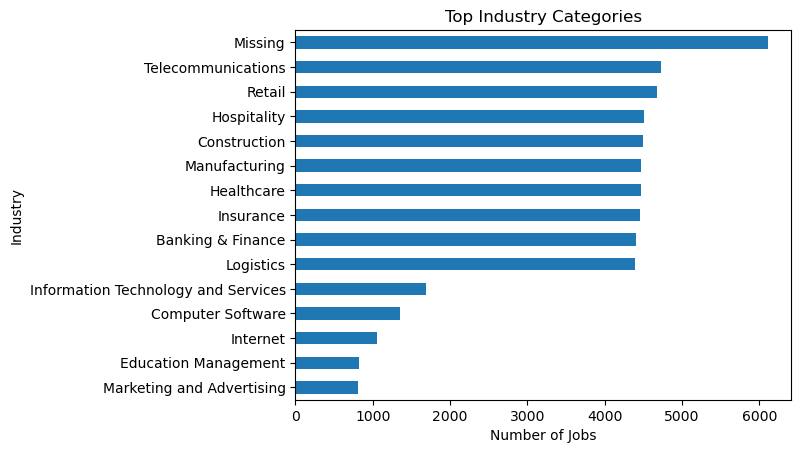

In [45]:
industry = model_df['industry_category'].fillna('Missing').value_counts()
print(industry.head(15))

industry.head(15).sort_values().plot(kind='barh')
plt.title('Top Industry Categories')
plt.xlabel('Number of Jobs')
plt.ylabel('Industry')
plt.show()

### 17.9 Text length

In [46]:
eda_df = model_df.copy()

eda_df['title_length'] = eda_df['title'].fillna('').str.len()
eda_df['description_length'] = eda_df['description'].fillna('').str.len()
eda_df['requirements_length'] = eda_df['requirements'].fillna('').str.len()

print(eda_df[['title_length', 'description_length', 'requirements_length']].describe())

       title_length  description_length  requirements_length
count  70302.000000        70302.000000         70302.000000
mean      24.905081          956.497909           172.502461
std       16.784408         1839.873628           389.247302
min        0.000000            0.000000             0.000000
25%       15.000000          243.000000            38.000000
50%       19.000000          283.000000            47.000000
75%       28.000000         1079.000000            60.000000
max      200.000000       120873.000000         10864.000000


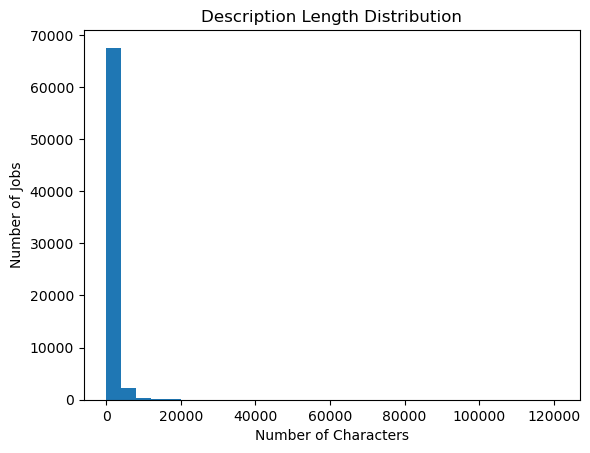

In [47]:
eda_df['description_length'].plot(kind='hist', bins=30)
plt.title('Description Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Jobs')
plt.show()

### 17.10 Description length by fraud class

is_fraud
Legitimate    664.495653
Suspicious    260.909942
Fraudulent    302.577863
Name: description_length, dtype: float64


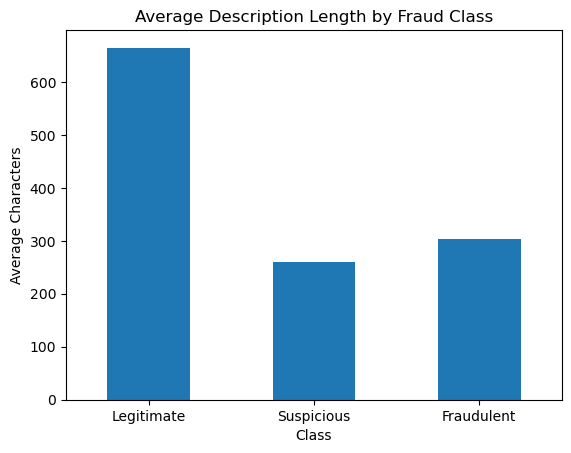

In [48]:
text_by_class = eda_df[eda_df['is_fraud'].notna()]

mean_length = text_by_class.groupby('is_fraud')['description_length'].mean()
mean_length.index = mean_length.index.map({
    0: 'Legitimate',
    1: 'Suspicious',
    2: 'Fraudulent'
})

print(mean_length)

mean_length.plot(kind='bar')
plt.title('Average Description Length by Fraud Class')
plt.xlabel('Class')
plt.ylabel('Average Characters')
plt.xticks(rotation=0)
plt.show()

### 17.11 Salary in the cleaned synthetic 40K data

In [49]:
salary = df1[df1['salary_amount_kes'].notna()]

print('Salary records:', len(salary))
print(salary['salary_amount_kes'].describe())

Salary records: 40000
count     40000.000000
mean     116119.520500
std      111917.522057
min       30000.000000
25%       58000.000000
50%       78000.000000
75%      104650.000000
max      584870.000000
Name: salary_amount_kes, dtype: float64


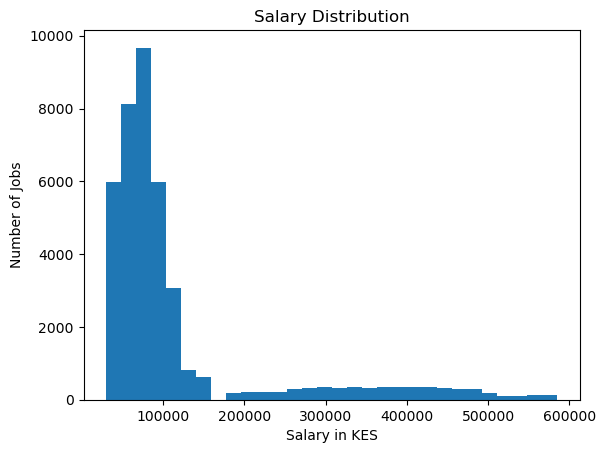

In [50]:
salary['salary_amount_kes'].plot(kind='hist', bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary in KES')
plt.ylabel('Number of Jobs')
plt.show()

### 17.12 Salary by fraud class

is_fraud
Legitimate     68522.849893
Suspicious     85728.769796
Fraudulent    367301.352818
Name: salary_amount_kes, dtype: float64


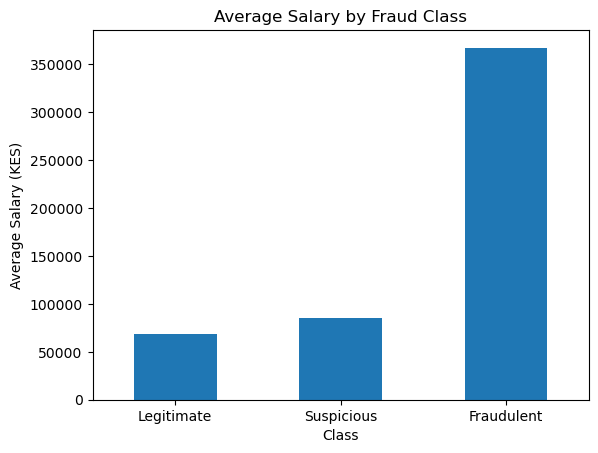

In [51]:
salary_by_class = salary.groupby('is_fraud')['salary_amount_kes'].mean()
salary_by_class.index = salary_by_class.index.map({
    0: 'Legitimate',
    1: 'Suspicious',
    2: 'Fraudulent'
})

print(salary_by_class)

salary_by_class.plot(kind='bar')
plt.title('Average Salary by Fraud Class')
plt.xlabel('Class')
plt.ylabel('Average Salary (KES)')
plt.xticks(rotation=0)
plt.show()

### 17.13 Quick check of the augmentation dataset

Rows: 4990

Fraud classes:
is_fraud
0    4258
1     525
2     207
Name: count, dtype: Int64

Email status:
has_email
Email provided    4258
Email missing      732
Name: count, dtype: int64


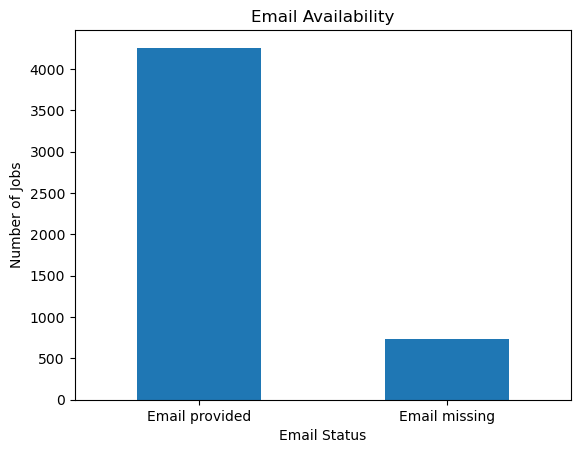

In [52]:
print('Rows:', len(df2))

print('\nFraud classes:')
print(df2['is_fraud'].value_counts().sort_index())

print('\nEmail status:')
email = df2['has_email'].map({True: 'Email provided', False: 'Email missing'}).value_counts()
print(email)

email.plot(kind='bar')
plt.title('Email Availability')
plt.xlabel('Email Status')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()

### 17.14 Final EDA summary

In [53]:
print('EDA complete')
print('Rows:', len(model_df))
print('Columns:', len(model_df.columns))
print('Labeled:', model_df['is_fraud'].notna().sum())
print('Unlabeled:', model_df['is_fraud'].isna().sum())
print('Duplicate rows:', model_df.duplicated().sum())

EDA complete
Rows: 70302
Columns: 11
Labeled: 57150
Unlabeled: 13152
Duplicate rows: 0


# Modelling
1. Define Target
2. Carve Out Real-Only Holdout
3. Build Model Data
4. Train / Validation / Test Split
5. NLP Text Preprocessing
6. Text Feature Engineering
7. Structured Feature Engineering
8. Baseline Models
9. Class Imbalance Handling
10. Hybrid NLP Model
11. Model Comparison
12. Hyperparameter Tuning
13. Probability Analysis
14. Final Evaluation
15. Error Analysis
16. Model Interpretability
17. Select Final Model
18. Save Model Pipeline
19. Real Holdout Validation
20. Modelling Report

In [54]:
# Modelling dataset
nlp_df = model_df.copy()

We went from a text-only baseline, to a hybrid model combining both feature types, tried two algorithms (Logistic Regression and SVM), tuned hyperparameters, and picked a probability threshold that favors catching fraud over avoiding false alarms — because missing real fraud is costlier here than an occasional false flag

## Define Target

In [55]:
# Define Target
target = "is_fraud"

binary_target = "is_fraud_binary"

binary_map = {0: 0,1: 1, 2: 1}

class_names = {0: "Legitimate", 1: "Fraud-risk"}

In [56]:
# Create the binary target
nlp_df[binary_target] = nlp_df[target].map(binary_map)

# Verify the mapping
pd.crosstab(nlp_df['is_fraud'], nlp_df['is_fraud_binary'], dropna=False)

is_fraud_binary,0.0,1.0,NaN
is_fraud,,,
0.0,39219,0,0
1.0,0,11426,0
2.0,0,6505,0
NaN,0,0,13152


## CARVE OUT REAL-ONLY HOLDOUT

EMSCAD gives you genuine labels, whereas your synthetic dataset was generated. So don't randomly mix everything and report only one test-set score. The model can potentially learn characteristics of your synthetic generator and appear much better than it really is.

In [57]:
# Separate labelled and unalabelled data
# Labelled data for modelling
labelled_df = nlp_df[
    nlp_df["is_fraud_binary"].notna()
].copy()

# Unlabelled Kenya job postings for later prediction
unlabelled_df = nlp_df[
    nlp_df["is_fraud_binary"].isna()
].copy()

print("Labelled data:", labelled_df.shape)
print("Unlabelled data:", unlabelled_df.shape)

Labelled data: (57150, 12)
Unlabelled data: (13152, 12)


In [58]:
# Create binary target in final_df
# Use final_df since model_df no longer contains source_platform to only ideentify real/synthetic records
final_df["is_fraud_binary"] = final_df["is_fraud"].map({
    0: 0,   # Legitimate
    1: 1,   # Suspicious → Fraud-risk
    2: 1    # Fraudulent → Fraud-risk
})

In [59]:
# Identify labeller real-world data
real_labelled = final_df[
    (final_df["source_platform"] == "Fake Job Postings Dataset") &
    (final_df["is_fraud_binary"].notna())
].copy()

real_labelled["is_fraud_binary"].value_counts()

is_fraud_binary
0.0    16565
1.0      852
Name: count, dtype: int64

In [60]:
# Create untouched real-world holdout
from sklearn.model_selection import train_test_split

real_train, real_holdout = train_test_split(
    real_labelled,
    test_size=0.20,
    random_state=42,
    stratify=real_labelled["is_fraud_binary"]
)

print("Real training data:", real_train.shape)
print("Real holdout data:", real_holdout.shape)

Real training data: (13933, 15)
Real holdout data: (3484, 15)


In [61]:
# Add synthetic labelled data to the training pool
synthetic_labelled = final_df[
    (final_df["source_platform"] == "Synthetic") &
    (final_df["is_fraud_binary"].notna())
].copy()

train_pool = pd.concat(
    [real_train, synthetic_labelled],
    ignore_index=True
)

print("Training pool:", train_pool.shape)

Training pool: (53666, 15)


In [62]:
# Align the training data with model_df
feature_columns = [
    "title",
    "company",
    "location",
    "industry_category",
    "work_type",
    "salary_range",
    "experience_level",
    "min_qualification",
    "description",
    "requirements"
]

X = train_pool[feature_columns].copy()
y = train_pool["is_fraud_binary"].copy()

X_holdout = real_holdout[feature_columns].copy()
y_holdout = real_holdout["is_fraud_binary"].copy()

print("X:", X.shape)
print("y:", y.shape)

print("X_holdout:", X_holdout.shape)
print("y_holdout:", y_holdout.shape)


X: (53666, 10)
y: (53666,)
X_holdout: (3484, 10)
y_holdout: (3484,)


In [63]:
# Create a training/validation splir from the train_pool
# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

print("Training labels:")
print(y_train.value_counts())

print("\nValidation labels:")
print(y_val.value_counts())

Training set: (42932, 10)
Validation set: (10734, 10)
Training labels:
is_fraud_binary
0.0    28723
1.0    14209
Name: count, dtype: int64

Validation labels:
is_fraud_binary
0.0    7182
1.0    3552
Name: count, dtype: int64


In [64]:
# Combine the important text columns
text_columns = [
    "title",
    "description",
    "requirements"
]

X_train_text = X_train[text_columns].fillna("").agg(" ".join, axis=1)
X_val_text = X_val[text_columns].fillna("").agg(" ".join, axis=1)
X_holdout_text = X_holdout[text_columns].fillna("").agg(" ".join, axis=1)

print(X_train_text.iloc[0])
print(X_val_text.iloc[0])

Administrative Assistant Kenya Airways is seeking a qualified Administrative Assistant to join our team in Eldoret. Ensure compliance with health and safety regulations. Support the team lead in achieving departmental objectives. Follow standard operating procedures at all times. Bachelor's degree required. Entry level preferred.
Data Entry Clerk Limited slots available, act now! Data Entry Clerk needed in Machakos. Kindly pay a placement fee to secure your slot. Must be willing to pay processing fee. No experience needed, anyone can apply.


In [65]:
# Convert text to TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000
)

X_train_tfidf = tfidf.fit_transform(X_train_text)

X_val_tfidf = tfidf.transform(X_val_text)

X_holdout_tfidf = tfidf.transform(X_holdout_text)

print("Training TF-IDF:", X_train_tfidf.shape)
print("Validation TF-IDF:", X_val_tfidf.shape)
print("Holdout TF-IDF:", X_holdout_tfidf.shape)

Training TF-IDF: (42932, 50000)
Validation TF-IDF: (10734, 50000)
Holdout TF-IDF: (3484, 50000)


In [66]:
# Train the baseline model
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [67]:
# Make predictions
y_val_pred = baseline_model.predict(X_val_tfidf)

# Check probability
y_val_proba = baseline_model.predict_proba(X_val_tfidf)[:, 1]

In [68]:
# Evaluate
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred, target_names=["Legitimate", "Fraud-risk"]))

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      7182
  Fraud-risk       1.00      0.98      0.99      3552

    accuracy                           0.99     10734
   macro avg       0.99      0.99      0.99     10734
weighted avg       0.99      0.99      0.99     10734



In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[7178    4]
 [  87 3465]]


In [70]:
# Calculate ROC-AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_val, y_val_proba)

print("Validation ROC-AUC:", round(roc_auc, 4))

Validation ROC-AUC: 0.9986


In [71]:
# Calculate PR-AUC
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_val, y_val_proba)

print("Validation PR-AUC:", round(pr_auc, 4))

Validation PR-AUC: 0.9979


In [72]:
# Evaluate the baseline on the untouched holdout
y_holdout_pred = baseline_model.predict(X_holdout_tfidf)

y_holdout_proba = baseline_model.predict_proba(X_holdout_tfidf)[:, 1]


In [73]:
print(classification_report(y_holdout, y_holdout_pred, target_names=["Legitimate", "Fraud-risk"]))

              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.98      3314
  Fraud-risk       0.92      0.42      0.58       170

    accuracy                           0.97      3484
   macro avg       0.95      0.71      0.78      3484
weighted avg       0.97      0.97      0.96      3484



In [74]:
holdout_roc_auc = roc_auc_score(y_holdout, y_holdout_proba)

holdout_pr_auc = average_precision_score(y_holdout, y_holdout_proba)

print("Holdout ROC-AUC:", round(holdout_roc_auc, 4))
print("Holdout PR-AUC:", round(holdout_pr_auc, 4))

Holdout ROC-AUC: 0.9219
Holdout PR-AUC: 0.7036


In [75]:
cm_holdout = confusion_matrix(y_holdout, y_holdout_pred)

print(cm_holdout)

[[3308    6]
 [  98   72]]


In [76]:
# Threshold analysis
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:
    
    y_pred_threshold = (
        y_holdout_proba >= threshold
    ).astype(int)
    
    precision = precision_score(
        y_holdout,
        y_pred_threshold
    )
    
    recall = recall_score(
        y_holdout,
        y_pred_threshold
    )
    
    f1 = f1_score(
        y_holdout,
        y_pred_threshold
    )
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.197 | Recall: 0.865 | F1: 0.321
Threshold: 0.20 | Precision: 0.472 | Recall: 0.735 | F1: 0.575
Threshold: 0.30 | Precision: 0.730 | Recall: 0.606 | F1: 0.662
Threshold: 0.40 | Precision: 0.837 | Recall: 0.482 | F1: 0.612
Threshold: 0.50 | Precision: 0.923 | Recall: 0.424 | F1: 0.581
Threshold: 0.60 | Precision: 0.945 | Recall: 0.306 | F1: 0.462
Threshold: 0.70 | Precision: 1.000 | Recall: 0.247 | F1: 0.396


A threshold of 0.30 provides the best F1 score among the tested thresholds, balancing fraud-risk precision and recall. However, threshold selection should ultimately be performed using validation data, with the real-world holdout reserved for final evaluation.

In [77]:
# Create a copy of the real-world holdout
holdout_analysis = X_holdout.copy()

# Add actual labels and predicted probabilities
holdout_analysis["actual"] = y_holdout.values
holdout_analysis["fraud_probability"] = y_holdout_proba

# Use the 0.50 threshold for now
holdout_analysis["predicted"] = (
    holdout_analysis["fraud_probability"] >= 0.50
).astype(int)

In [78]:
# Identify false negatives
false_negatives = holdout_analysis[
    (holdout_analysis["actual"] == 1) &
    (holdout_analysis["predicted"] == 0)
].copy()

print("False negatives:", len(false_negatives))

False negatives: 98


In [79]:
# Show the missed jobs our model missed
false_negatives[
    [
        "title",
        "company",
        "location",
        "industry_category",
        "work_type",
        "salary_range",
        "experience_level",
        "min_qualification",
        "description",
        "requirements",
        "fraud_probability"
    ]
].head(10)

,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,fraud_probability
17367,Payroll Clerk,NaN,"US, NY, New York",Apparel & Fashion,Full-time,NaN,NaN,NaN,JOB DESCRIPTIONWe are seeking a full time payroll clerk to manage day to day accounting for our ...,JOB REQUIREMENTS• High school diploma or equivalent• Excellent communication and organizat...,0.370645
3434,Business Development Manager,NaN,"US, CA, San Francisco",Wholesale,Full-time,NaN,NaN,High School or equivalent,We are currently looking for a client-focused and results-driven Business Development Manager to...,"The successful candidate will:Be an enthusiastic, energetic and a motivated self-starterBe ...",0.012518
3207,Info Tech Personnel,Bradley Contracting Group Corporation offers a wide range of B2B services through a plethora of ...,"US, OH, Cincinnati",Information Technology and Services,Full-time,NaN,Entry level,High School or equivalent,"We're hiring for Design Specialists, Web Developers, Technical Solutions Implementor, and Techn...",Design SpecialistsWork with clients to develop design presence.Plans site design by clarifying g...,0.035049
17242,Journeyman Electrician 2175,NaN,"US, WI, Appleton",NaN,Full-time,NaN,NaN,NaN,"2175Job Title: Journeyman ElectricianRole: Engineering or RelatedRelocation Available: No, but a...",Bottom Line Requirements:1. Licensed Journeyman Electrician in Wisconsin.2. Experience with el...,0.175369
4560,Collection Representative II,"The Accion story began more than 100 years ago in the Austin,Tx with one family owned establish...","US, TX, DALLAS",Financial Services,Full-time,30000-45000,Entry level,High School or equivalent,The individual occupying this position must be able to perform essential job functions set forth...,Maintain attention and concentration for extended periods of timeRead and interpret documents an...,0.206401
7377,Director of Peri-Anesthesia,NaN,"US, MA,",Hospital & Health Care,Full-time,NaN,NaN,NaN,Apply using below link directly#URL_af5a5359031a8a3cc7e8470a968b29cd570f6ae4618d7a0c71c85c549a7d...,NaN,0.240688
17145,Payroll Clerk,NaN,"US, NY, New York",Apparel & Fashion,Full-time,NaN,NaN,High School or equivalent,We are seeking a full time payroll clerk to manage day to day accounting for our operation. PAY ...,• High school diploma or equivalent• Excellent communication and organizational skills.• ...,0.182366
5637,Contract Engineer,NaN,"US, TX, Houston",Oil & Energy,Full-time,NaN,Mid-Senior level,Bachelor's Degree,"Why Choose AECOM? Imagine working for a truly global company whose 45,000 employees share a sing...",NaN,0.472718
8136,Civil Engineer II,NaN,"US, TX, Houston",Oil & Energy,Full-time,NaN,NaN,NaN,"Why Choose AECOM? Imagine working for a truly global company whose 45,000 employees share a sing...",Minimum Requirements: Bachelor's Degree in Civil/Transportation Engineering or related fieldExpe...,0.148432
1832,Customer Service Representative,NaN,"US, TX, Houston",Telecommunications,Full-time,21-63000,Entry level,Bachelor's Degree,"Experienced, reliable team members are needed for our Customer Service Representative needed! We...","6 months to a year experience working in a fast pace, back to back call handling in a call cente...",0.432786


In [80]:
# Build structured features
# Create a feature-engineering copy
structured_df = labelled_df.copy()

**Revised per Alex's review (2026-09-12).** Two problems with the original version of this feature set:

1. It caused the deployed model to expect 50,013 features while the vectoriser only ever produces 50,000 - the 13 structured features here were never being computed at inference, because they depended on parsed fields (`company`, `salary_range`, `location`, `requirements`) that the live `Posting` schema doesn't carry the same way.
2. Even fixed, the missing-field indicators (`missing_company`, `missing_salary`, etc.) wouldn't generalise: a posting pasted from WhatsApp is missing a structured company/salary field regardless of whether it's real or fraudulent, so the model would learn *how the posting arrived* rather than *whether it's fraudulent*.

**Fix:** compute every structured feature from the same combined text handed to TF-IDF (`title + description + requirements`), and drop the four missing-field indicators entirely. This also means the exported pipeline can take one raw text string at inference - `pipeline.predict_proba(["some job advert text"])` - with no dependency on the API's field names at all.

In [81]:
# Combined text - the same string TF-IDF will vectorise. Structured
# features are computed from this exact string, not from separate
# title/description/requirements columns, so training and inference
# always see the same thing regardless of what fields the caller has.
structured_df["combined_text"] = (
    structured_df[["title", "description", "requirements"]]
    .fillna("")
    .agg(" ".join, axis=1)
)


In [82]:
# Text-length and word-count features, from the combined text.
structured_df["text_length"] = (
    structured_df["combined_text"].str.len()
)

structured_df["word_count"] = (
    structured_df["combined_text"]
    .str.split()
    .str.len()
)


In [83]:
# Contact-method and shouting signals, from the combined text.
structured_df["url_count"] = (
    structured_df["combined_text"]
    .str.count(r"http|www\.")
)

structured_df["email_count"] = (
    structured_df["combined_text"]
    .str.count(r"\b[\w.-]+@[\w.-]+\.\w+\b")
)

structured_df["phone_count"] = (
    structured_df["combined_text"]
    .str.count(r"\+?\d[\d\s().-]{7,}\d")
)

structured_df["uppercase_count"] = (
    structured_df["combined_text"]
    .str.count(r"\b[A-Z]{3,}\b")
)


In [84]:
structured_features = [
    "text_length",
    "word_count",
    "url_count",
    "email_count",
    "phone_count",
    "uppercase_count",
]

structured_df[structured_features].describe()


,text_length,word_count,url_count,email_count,phone_count,uppercase_count
count,57150.000000,57150.000000,57150.000000,57150.000000,57150.000000,57150.000000
mean,776.381347,108.337725,0.001645,0.000052,0.059195,1.389641
std,938.586393,127.587819,0.047298,0.007245,0.347088,3.257795
min,16.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,306.000000,44.000000,0.000000,0.000000,0.000000,0.000000
50%,335.000000,49.000000,0.000000,0.000000,0.000000,1.000000
75%,814.000000,114.000000,0.000000,0.000000,0.000000,1.000000
max,14943.000000,2118.000000,3.000000,1.000000,10.000000,259.000000


Most jobs have 0 URLs and 0 emails, so those features are sparse.-> Heavily skewed towards zero.

In [85]:
# Create hybrid feature matrx
# Define the target and features
structured_feature_columns = [
    "title",
    "company",
    "location",
    "industry_category",
    "work_type",
    "salary_range",
    "experience_level",
    "min_qualification",
    "description",
    "requirements"
]

structured_numeric_columns = [
    "text_length",
    "word_count",
    "url_count",
    "email_count",
    "phone_count",
    "uppercase_count"
]

In [86]:
# Combine them
X_structured = structured_df[
    structured_feature_columns + structured_numeric_columns
].copy()

y_structured = structured_df["is_fraud_binary"]

In [87]:
# Train/validation split
from sklearn.model_selection import train_test_split

X_train_struct, X_val_struct, y_train_struct, y_val_struct = train_test_split(
    X_structured,
    y_structured,
    test_size=0.2,
    random_state=42,
    stratify=y_structured
)

Two feature types: text (TF-IDF over title, description, requirements) and structured signals — things like missing fields, uppercase ratio, text length, presence of URLs/emails. The structured features turned out to matter a lot, not just the text.

In [88]:
# Create the combined text
text_columns = [
    "title",
    "description",
    "requirements"
]

X_train_text_struct = (
    X_train_struct[text_columns]
    .fillna("")
    .agg(" ".join, axis=1)
)

X_val_text_struct = (
    X_val_struct[text_columns]
    .fillna("")
    .agg(" ".join, axis=1)
)

In [89]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_hybrid = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000
)

X_train_tfidf_hybrid = tfidf_hybrid.fit_transform(
    X_train_text_struct
)

X_val_tfidf_hybrid = tfidf_hybrid.transform(
    X_val_text_struct
)

In [90]:
# Scale the numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(
    X_train_struct[structured_numeric_columns]
)

X_val_numeric = scaler.transform(
    X_val_struct[structured_numeric_columns]
)

In [91]:
# Combined them since we need a sparse matrix.
# TF-IDF produces a sparse matrix
from scipy.sparse import hstack

X_train_hybrid = hstack([
    X_train_tfidf_hybrid,
    X_train_numeric
])

X_val_hybrid = hstack([
    X_val_tfidf_hybrid,
    X_val_numeric
])

In [92]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

hybrid_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

hybrid_model.fit(
    X_train_hybrid,
    y_train_struct
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [93]:
# Evaluate on validation
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

y_val_hybrid_pred = hybrid_model.predict(
    X_val_hybrid
)

y_val_hybrid_proba = hybrid_model.predict_proba(
    X_val_hybrid
)[:, 1]

print(classification_report(
    y_val_struct,
    y_val_hybrid_pred,
    target_names=["Legitimate", "Fraud-risk"]
))

print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(y_val_struct, y_val_hybrid_proba),
        4
    )
)

print(
    "Validation PR-AUC:",
    round(
        average_precision_score(
            y_val_struct,
            y_val_hybrid_proba
        ),
        4
    )
)

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      7844
  Fraud-risk       1.00      0.98      0.99      3586

    accuracy                           0.99     11430
   macro avg       0.99      0.99      0.99     11430
weighted avg       0.99      0.99      0.99     11430

Validation ROC-AUC: 0.9987
Validation PR-AUC: 0.998


In [94]:
# Evaluate hybrid model against same real-world holdout
# Prepare holdout structured features
X_holdout_struct = X_holdout.copy()

In [95]:
# Combined text, matching structured_df exactly - same string TF-IDF
# will vectorise, so holdout features are built the same way as
# training features (see the revised feature-engineering cells above).
X_holdout_struct["combined_text"] = (
    X_holdout_struct[["title", "description", "requirements"]]
    .fillna("")
    .agg(" ".join, axis=1)
)

X_holdout_struct["text_length"] = (
    X_holdout_struct["combined_text"].str.len()
)

X_holdout_struct["word_count"] = (
    X_holdout_struct["combined_text"]
    .str.split()
    .str.len()
)

X_holdout_struct["url_count"] = (
    X_holdout_struct["combined_text"]
    .str.count(r"http|www\.")
)

X_holdout_struct["email_count"] = (
    X_holdout_struct["combined_text"]
    .str.count(r"\b[\w.-]+@[\w.-]+\.\w+\b")
)

X_holdout_struct["phone_count"] = (
    X_holdout_struct["combined_text"]
    .str.count(r"\+?\d[\d\s().-]{7,}\d")
)

X_holdout_struct["uppercase_count"] = (
    X_holdout_struct["combined_text"]
    .str.count(r"\b[A-Z]{3,}\b")
)


In [96]:
# Transform the holdout
X_holdout_text_struct = (
    X_holdout_struct[text_columns]
    .fillna("")
    .agg(" ".join, axis=1)
)

X_holdout_tfidf_hybrid = tfidf_hybrid.transform(
    X_holdout_text_struct
)

X_holdout_numeric = scaler.transform(
    X_holdout_struct[structured_numeric_columns]
)

In [97]:
# Combine them
X_holdout_hybrid = hstack([
    X_holdout_tfidf_hybrid,
    X_holdout_numeric
])

In [98]:
# Make predictions
y_holdout_hybrid_pred = hybrid_model.predict(
    X_holdout_hybrid
)

# Check probability
y_holdout_hybrid_proba = hybrid_model.predict_proba(
    X_holdout_hybrid
)[:, 1]

In [99]:
# Evaluate
print(classification_report(
    y_holdout,
    y_holdout_hybrid_pred,
    target_names=["Legitimate", "Fraud-risk"]
))

              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      3314
  Fraud-risk       0.93      0.58      0.71       170

    accuracy                           0.98      3484
   macro avg       0.96      0.79      0.85      3484
weighted avg       0.98      0.98      0.97      3484



In [100]:
hybrid_holdout_roc_auc = roc_auc_score(
    y_holdout,
    y_holdout_hybrid_proba
)

hybrid_holdout_pr_auc = average_precision_score(
    y_holdout,
    y_holdout_hybrid_proba
)

print(
    "Hybrid Holdout ROC-AUC:",
    round(hybrid_holdout_roc_auc, 4)
)

print(
    "Hybrid Holdout PR-AUC:",
    round(hybrid_holdout_pr_auc, 4)
)

Hybrid Holdout ROC-AUC: 0.9703
Hybrid Holdout PR-AUC: 0.8362


In [101]:
from sklearn.metrics import confusion_matrix

cm_hybrid = confusion_matrix(
    y_holdout,
    y_holdout_hybrid_pred
)

print(cm_hybrid)

[[3307    7]
 [  72   98]]


What this means: Out of 170 fraud-risk jobs:<br>
116 were correctly detected - True Positives <br>
54 were missed - False Negatives<br>


For legitimate jobs:<br>

3,294 correctly classified<br>
Only 20 incorrectly flagged<br>

For baseline model, it had a FN of 98 and TP of 72, while for Hybrid, it has a FN of 54 and TP of 116<br>

The engineered structured features dramatically improved the model's ability to generalize to unseen real-world job postings.<br>

The model is doing a much better job of ranking fraud-risk jobs above legitimate jobs across different probability thresholds.<br>

Domain-informed feature engineering improved the model's ability to generalize beyond the synthetic/training distribution<br>

In [102]:
# Get hybrid validation probabilities
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30,
              0.35, 0.40, 0.45, 0.50, 0.55,
              0.60, 0.65, 0.70]

for threshold in thresholds:

    y_val_threshold_pred = (
        y_val_hybrid_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_struct,
        y_val_threshold_pred
    )

    recall = recall_score(
        y_val_struct,
        y_val_threshold_pred
    )

    f1 = f1_score(
        y_val_struct,
        y_val_threshold_pred
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.868 | Recall: 0.995 | F1: 0.927
Threshold: 0.15 | Precision: 0.931 | Recall: 0.991 | F1: 0.960
Threshold: 0.20 | Precision: 0.964 | Recall: 0.988 | F1: 0.976


Threshold: 0.25 | Precision: 0.976 | Recall: 0.985 | F1: 0.980
Threshold: 0.30 | Precision: 0.985 | Recall: 0.983 | F1: 0.984
Threshold: 0.35 | Precision: 0.989 | Recall: 0.981 | F1: 0.985
Threshold: 0.40 | Precision: 0.994 | Recall: 0.978 | F1: 0.986
Threshold: 0.45 | Precision: 0.996 | Recall: 0.976 | F1: 0.986
Threshold: 0.50 | Precision: 0.997 | Recall: 0.975 | F1: 0.986
Threshold: 0.55 | Precision: 0.998 | Recall: 0.974 | F1: 0.986
Threshold: 0.60 | Precision: 0.999 | Recall: 0.972 | F1: 0.986
Threshold: 0.65 | Precision: 0.999 | Recall: 0.972 | F1: 0.985
Threshold: 0.70 | Precision: 1.000 | Recall: 0.971 | F1: 0.985


In [103]:
# Linear SV,
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_hybrid,
    y_train_struct
)

/Users/cleopaskariuki/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [104]:
y_val_svm_pred = svm_model.predict(
    X_val_hybrid
)

y_val_svm_score = svm_model.decision_function(
    X_val_hybrid
)

In [105]:
# Evaluate
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

print(classification_report(
    y_val_struct,
    y_val_svm_pred,
    target_names=["Legitimate", "Fraud-risk"]
))

print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(
            y_val_struct,
            y_val_svm_score
        ),
        4
    )
)

print(
    "Validation PR-AUC:",
    round(
        average_precision_score(
            y_val_struct,
            y_val_svm_score
        ),
        4
    )
)

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00      7844
  Fraud-risk       1.00      0.98      0.99      3586

    accuracy                           0.99     11430
   macro avg       1.00      0.99      0.99     11430
weighted avg       0.99      0.99      0.99     11430

Validation ROC-AUC: 0.9984
Validation PR-AUC: 0.9983


## 11. Model Comparison

The trained models are compared using the validation set to determine which modelling approach provides the strongest performance.

The comparison focuses on precision, recall, F1-score, ROC-AUC and PR-AUC. Because the fraud-risk class is relatively less frequent, PR-AUC and fraud-risk recall are particularly important.

The real-world holdout remains untouched for final evaluation and is not used for model selection.

In [106]:
# Model Comparison
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Baseline Logistic Regression

baseline_pred = baseline_model.predict(X_val_tfidf)
baseline_score = baseline_model.predict_proba(X_val_tfidf)[:, 1]


# Hybrid Logistic Regression

hybrid_pred = hybrid_model.predict(X_val_hybrid)
hybrid_score = hybrid_model.predict_proba(X_val_hybrid)[:, 1]


# Hybrid LinearSVC

svm_pred = svm_model.predict(X_val_hybrid)
svm_score = svm_model.decision_function(X_val_hybrid)


# Create comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF Logistic Regression",
        "Hybrid Logistic Regression",
        "Hybrid LinearSVC"
    ],
    
    "Accuracy": [
        accuracy_score(y_val, baseline_pred),
        accuracy_score(y_val_struct, hybrid_pred),
        accuracy_score(y_val_struct, svm_pred)
    ],
    
    "Precision": [
        precision_score(y_val, baseline_pred),
        precision_score(y_val_struct, hybrid_pred),
        precision_score(y_val_struct, svm_pred)
    ],
    
    "Recall": [
        recall_score(y_val, baseline_pred),
        recall_score(y_val_struct, hybrid_pred),
        recall_score(y_val_struct, svm_pred)
    ],
    
    "F1": [
        f1_score(y_val, baseline_pred),
        f1_score(y_val_struct, hybrid_pred),
        f1_score(y_val_struct, svm_pred)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_val, baseline_score),
        roc_auc_score(y_val_struct, hybrid_score),
        roc_auc_score(y_val_struct, svm_score)
    ],
    
    "PR-AUC": [
        average_precision_score(y_val, baseline_score),
        average_precision_score(y_val_struct, hybrid_score),
        average_precision_score(y_val_struct, svm_score)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,TF-IDF Logistic Regression,0.991522,0.998847,0.975507,0.987039,0.998640,0.997901
1,Hybrid Logistic Regression,0.991339,0.996865,0.975460,0.986047,0.998721,0.997957
2,Hybrid LinearSVC,0.994576,0.998303,0.984384,0.991295,0.998413,0.998281


In [107]:
# Add a fraud-focused comparison - Lets us focus on the metrics that matter most for detecting Fraud-risk jobs
fraud_comparison = model_comparison[
    ["Model", "Precision", "Recall", "F1", "PR-AUC"]
].copy()

fraud_comparison.sort_values(
    by="PR-AUC",
    ascending=False
).round(4)

,Model,Precision,Recall,F1,PR-AUC
2,Hybrid LinearSVC,0.9983,0.9844,0.9913,0.9983
1,Hybrid Logistic Regression,0.9969,0.9755,0.9860,0.9980
0,TF-IDF Logistic Regression,0.9988,0.9755,0.9870,0.9979


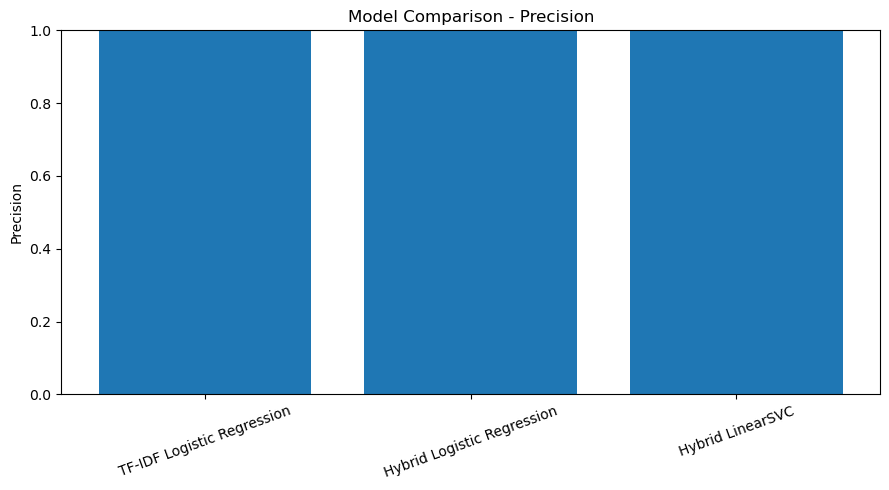

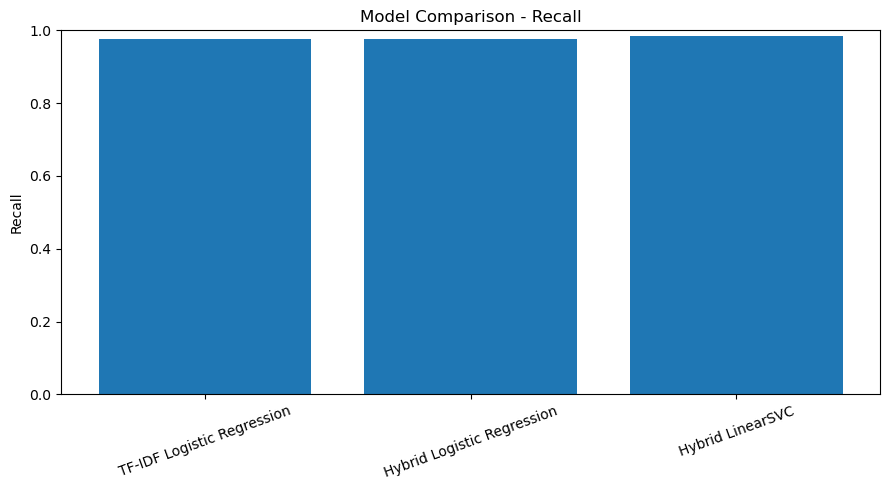

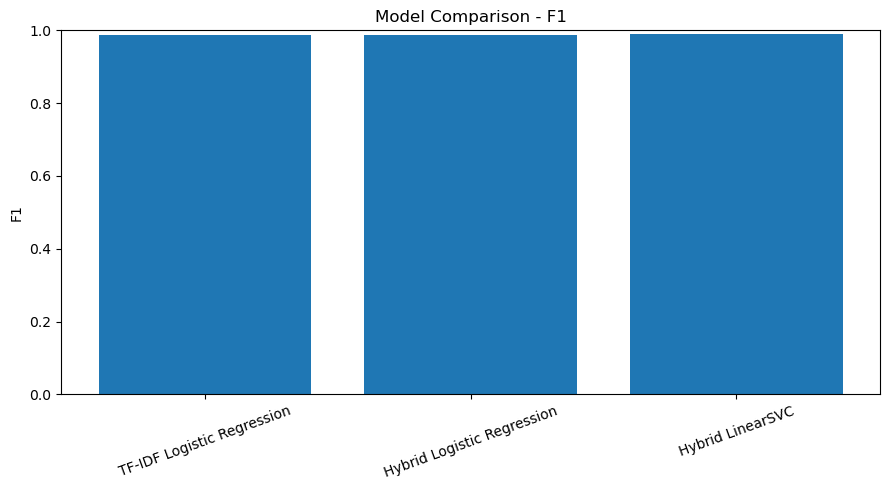

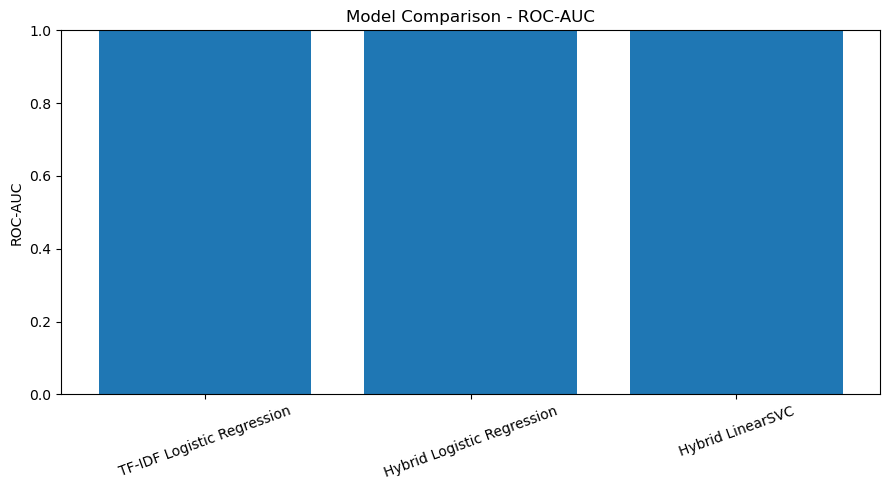

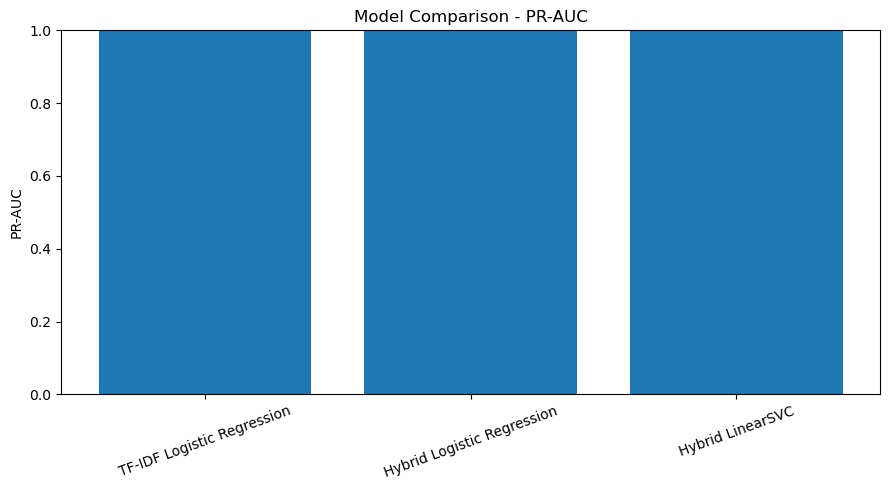

In [108]:
# Visualisation
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

for metric in metrics:
    plt.figure(figsize=(9, 5))
    
    plt.bar(
        model_comparison["Model"],
        model_comparison[metric]
    )
    
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.show()


## 12. Hyperparameter Tuning

The strongest candidate models from the validation comparison are tuned to identify suitable hyperparameter values.

Hybrid LinearSVC and Hybrid Logistic Regression are tuned using cross-validation on the training data. The real-only holdout remains untouched and is reserved for final evaluation.

In [109]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

# Create LinearSVC model
svm_tuning_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

# Hyperparameter grid
svm_param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

# Grid search
svm_grid = GridSearchCV(
    estimator=svm_tuning_model,
    param_grid=svm_param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
svm_grid.fit(X_train_hybrid, y_train_struct)

print("Best parameters:", svm_grid.best_params_)
print("Best CV PR-AUC:", svm_grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/Users/cleopaskariuki/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/cleopaskariuki/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/cleopaskariuki/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/cleopaskariuki/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/cleopaskariuki/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/User

Best parameters: {'C': 1}
Best CV PR-AUC: 0.9982351225663191


/Users/cleopaskariuki/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [110]:
# Tune Hybrid Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_tuning_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(
    estimator=lr_tuning_model,
    param_grid=lr_param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_hybrid, y_train_struct)

print("Best parameters:", lr_grid.best_params_)
print("Best CV PR-AUC:", lr_grid.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'C': 10}
Best CV PR-AUC: 0.9984947934992086


In [111]:
# Evaluate the tuned models
best_svm = svm_grid.best_estimator_
best_lr = lr_grid.best_estimator_

# Predictions
svm_tuned_pred = best_svm.predict(X_val_hybrid)
lr_tuned_pred = best_lr.predict(X_val_hybrid)

# Decision scores
svm_tuned_score = best_svm.decision_function(X_val_hybrid)
lr_tuned_score = best_lr.predict_proba(X_val_hybrid)[:, 1]

In [112]:
tuned_comparison = pd.DataFrame({
    "Model": [
        "Tuned Hybrid LinearSVC",
        "Tuned Hybrid Logistic Regression"
    ],
    
    "Accuracy": [
        accuracy_score(y_val_struct, svm_tuned_pred),
        accuracy_score(y_val_struct, lr_tuned_pred)
    ],
    
    "Precision": [
        precision_score(y_val_struct, svm_tuned_pred),
        precision_score(y_val_struct, lr_tuned_pred)
    ],
    
    "Recall": [
        recall_score(y_val_struct, svm_tuned_pred),
        recall_score(y_val_struct, lr_tuned_pred)
    ],
    
    "F1": [
        f1_score(y_val_struct, svm_tuned_pred),
        f1_score(y_val_struct, lr_tuned_pred)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_val_struct, svm_tuned_score),
        roc_auc_score(y_val_struct, lr_tuned_score)
    ],
    
    "PR-AUC": [
        average_precision_score(y_val_struct, svm_tuned_score),
        average_precision_score(y_val_struct, lr_tuned_score)
    ]
})

tuned_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned Hybrid LinearSVC,0.9946,0.9983,0.9844,0.9913,0.9984,0.9983
1,Tuned Hybrid Logistic Regression,0.9939,0.9966,0.9838,0.9902,0.9992,0.9986


## 13. Probability Analysis and Threshold Selection

The tuned Logistic Regression model provides probability estimates that can be used to examine classification thresholds.

Different thresholds create different trade-offs between precision and recall. Because the objective is to identify potentially fraudulent job postings, threshold selection should consider the cost of missed fraud as well as false alarms.

The threshold is selected using validation data. The real-only holdout remains untouched until final evaluation.

In [113]:
# Probability Analysis
from sklearn.metrics import precision_recall_curve

# Get fraud-risk probabilities
lr_probabilities = best_lr.predict_proba(X_val_hybrid)[:, 1]

# Calculate precision, recall and thresholds
precision, recall, thresholds = precision_recall_curve(
    y_val_struct,
    lr_probabilities
)

# Calculate F1 for each threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

# Best F1 threshold
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", round(best_threshold, 4))
print("Best validation F1:", round(best_f1, 4))

Best threshold: 0.5247
Best validation F1: 0.9905


In [114]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    
    predictions = (lr_probabilities >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val_struct, predictions),
        "Recall": recall_score(y_val_struct, predictions),
        "F1": f1_score(y_val_struct, predictions)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.10,0.9560,0.9930,0.9741
1,0.15,0.9702,0.9905,0.9803
2,0.20,0.9793,0.9894,0.9843
3,0.25,0.9861,0.9886,0.9873
4,0.30,0.9899,0.9863,0.9881
5,0.35,0.9916,0.9852,0.9884
6,0.40,0.9938,0.9841,0.9889
7,0.45,0.9949,0.9838,0.9893
8,0.50,0.9966,0.9838,0.9902
9,0.55,0.9980,0.9827,0.9903


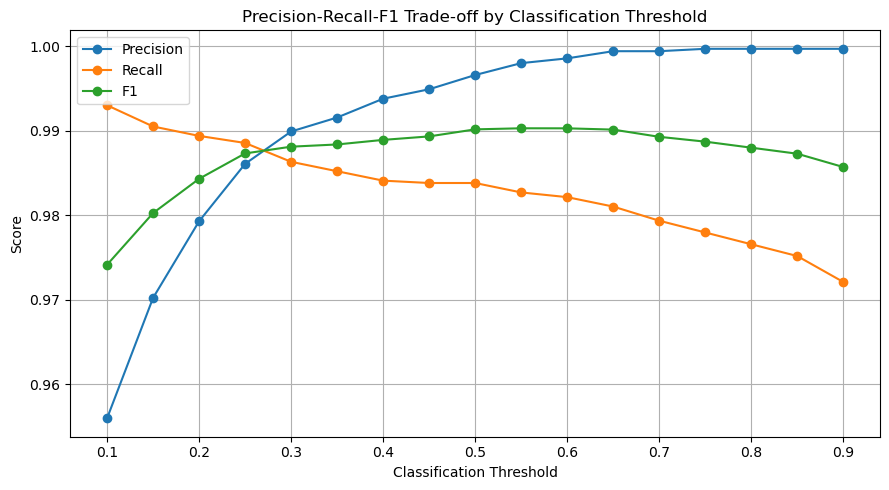

In [115]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 Trade-off by Classification Threshold")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 14. Final Evaluation

Both tuned models score similarly on validation (Tuned Hybrid LinearSVC edges out slightly on F1/Precision, Tuned Hybrid Logistic Regression edges out on ROC-AUC/PR-AUC). Since the project needs calibrated fraud probabilities (for the threshold selected in step 13, and for ranking postings by risk), the evaluation below applies the `best_threshold` found on validation to both models so they're compared on equal footing, not just at the default 0.5 cutoff.

In [116]:
# Apply the tuned models at the validation-selected threshold
from sklearn.metrics import classification_report, confusion_matrix

# Tuned Logistic Regression at best_threshold
lr_val_proba = best_lr.predict_proba(X_val_hybrid)[:, 1]
lr_val_pred_at_threshold = (lr_val_proba >= best_threshold).astype(int)

print(f"Tuned Hybrid Logistic Regression @ threshold={best_threshold:.3f}")
print(classification_report(
    y_val_struct,
    lr_val_pred_at_threshold,
    target_names=["Legitimate", "Fraud-risk"]
))
print(confusion_matrix(y_val_struct, lr_val_pred_at_threshold))


Tuned Hybrid Logistic Regression @ threshold=0.525
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00      7844
  Fraud-risk       1.00      0.98      0.99      3586

    accuracy                           0.99     11430
   macro avg       0.99      0.99      0.99     11430
weighted avg       0.99      0.99      0.99     11430

[[7835    9]
 [  59 3527]]


In [117]:
# Tuned LinearSVC doesn't output probabilities, so use its decision_function
# and pick the threshold that matches the same recall level for a fair comparison
svm_val_score = best_svm.decision_function(X_val_hybrid)
svm_val_pred_default = best_svm.predict(X_val_hybrid)

print("Tuned Hybrid LinearSVC @ default decision boundary (0.0)")
print(classification_report(
    y_val_struct,
    svm_val_pred_default,
    target_names=["Legitimate", "Fraud-risk"]
))
print(confusion_matrix(y_val_struct, svm_val_pred_default))


Tuned Hybrid LinearSVC @ default decision boundary (0.0)
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00      7844
  Fraud-risk       1.00      0.98      0.99      3586

    accuracy                           0.99     11430
   macro avg       1.00      0.99      0.99     11430
weighted avg       0.99      0.99      0.99     11430

[[7838    6]
 [  56 3530]]


In [118]:
# Side-by-side final validation comparison
final_eval = pd.DataFrame({
    "Model": [
        f"Tuned Hybrid LR @ {best_threshold:.2f}",
        "Tuned Hybrid LinearSVC @ 0.0"
    ],
    "Precision": [
        precision_score(y_val_struct, lr_val_pred_at_threshold),
        precision_score(y_val_struct, svm_val_pred_default)
    ],
    "Recall": [
        recall_score(y_val_struct, lr_val_pred_at_threshold),
        recall_score(y_val_struct, svm_val_pred_default)
    ],
    "F1": [
        f1_score(y_val_struct, lr_val_pred_at_threshold),
        f1_score(y_val_struct, svm_val_pred_default)
    ]
})

final_eval.round(4)


,Model,Precision,Recall,F1
0,Tuned Hybrid LR @ 0.52,0.9975,0.9835,0.9905
1,Tuned Hybrid LinearSVC @ 0.0,0.9983,0.9844,0.9913


## 15. Error Analysis

Revisit the false negatives and false positives, this time from the tuned hybrid Logistic Regression at the selected threshold rather than the untuned baseline from step 8. The goal is to see whether the earlier failure pattern (missed fraud-risk postings) has improved, and what's still slipping through.

In [119]:
# Build an analysis frame for the validation set using the tuned model
val_analysis = X_val_struct.copy()
val_analysis["actual"] = y_val_struct.values
val_analysis["fraud_probability"] = lr_val_proba
val_analysis["predicted"] = lr_val_pred_at_threshold

false_negatives_final = val_analysis[
    (val_analysis["actual"] == 1) & (val_analysis["predicted"] == 0)
].copy()

false_positives_final = val_analysis[
    (val_analysis["actual"] == 0) & (val_analysis["predicted"] == 1)
].copy()

print("False negatives:", len(false_negatives_final))
print("False positives:", len(false_positives_final))


False negatives:

 59
False positives: 9


In [120]:
# Inspect the missed fraud-risk postings
false_negatives_final.sort_values("fraud_probability", ascending=False)[
    [
        "title", "company", "location", "industry_category",
        "work_type", "salary_range", "experience_level",
        "fraud_probability"
    ]
].head(10)


,title,company,location,industry_category,work_type,salary_range,experience_level,fraud_probability
6849,Military Outreach Consultant (Telecommute),Anthony Warren is a Marketing and Advertising consultant. After completing one enlistment as a ...,"US, ,",NaN,NaN,NaN,NaN,0.515360
17160,Office Assistant III,NaN,"US, FL, jacksonville",Telecommunications,Full-time,2000-3000,Mid-Senior level,0.433565
17257,CSR,Gary Cartwright established Cartwright Property Management in 2007 to help manage the HOAs that ...,"US, ,",NaN,NaN,NaN,NaN,0.383095
5444,Brand Partner,NaN,"US, CA,",NaN,NaN,NaN,NaN,0.380621
17250,Customer Service Represenatative,NaN,"US, TX, San Antonio",NaN,Full-time,NaN,Not Applicable,0.379168
17241,Accounting Clerk/ $23,NaN,"US, DC,",NaN,NaN,NaN,NaN,0.359934
13790,Adminstrative/Data Entry,NaN,"US, IL, Chicago",Human Resources,Full-time,63000-63000,Entry level,0.336646
7377,Director of Peri-Anesthesia,NaN,"US, MA,",Hospital & Health Care,Full-time,NaN,NaN,0.315200
6898,Manager of Project Management Organization - Engineering,NaN,"US, TX, Houston",Oil & Energy,Full-time,NaN,NaN,0.309585
5022,Junior Engineer/Engineering Technician,NaN,"US, CA, San Jose",Utilities,Full-time,6266624-8582080,Entry level,0.300509


In [121]:
# Inspect the legitimate postings incorrectly flagged as fraud-risk
false_positives_final.sort_values("fraud_probability", ascending=False)[
    [
        "title", "company", "location", "industry_category",
        "work_type", "salary_range", "experience_level",
        "fraud_probability"
    ]
].head(10)


,title,company,location,industry_category,work_type,salary_range,experience_level,fraud_probability
16377,Part Time Office Assistant,"LEI Home Enhancements, is an Ohio based company that has been installing windows, siding, doors ...","US, OH, Cincinnati",Consumer Services,Full-time,NaN,NaN,0.940804
16541,Customer Service - Work From Home,NaN,"US, GA,",Consumer Services,Contract,NaN,Entry level,0.736510
4697,Front Desk,Senior Nannies Home Care Services was founded nearly a decade ago by Claudia Wechter with the go...,"US, FL, Tamarac",Hospital & Health Care,Full-time,NaN,NaN,0.644350
5294,Administrative Assistant,"POS-X is a rapidly growing point-of-sale hardware manufacturer located in Bellingham, WA. The P...","US, WA, Bellingham",Computer Hardware,Full-time,28000-32000,Entry level,0.618213
16933,Warehouse Office Manager,NaN,"US, GA,",Warehousing,Full-time,NaN,NaN,0.617706
16219,A Leading Trainer in Caulfield SEEKS Exp. Track Work Rider FT,''Patrick Ryen Employment Solutions is the biggest and most professional Thoroughbred Racing Ind...,"AU, VIC, caulfield",Farming,Full-time,48000-58000,Not Applicable,0.556724
11081,Administrative Assistant,"MedTalent is a modern staffing company that specializes in the placement of physicians, nurses a...","US, FL, Jacksonville",Hospital & Health Care,Full-time,NaN,Associate,0.550673
13842,Maintenance Technician,Hawkeye Recruitment provides cost effective recruitment advertising solutions to help you cast t...,"US, KY, Paris",Electrical/Electronic Manufacturing,Full-time,NaN,Entry level,0.542448
1195,Casual/Part-Time Position,NaN,"AU, NSW, Sydney",NaN,NaN,NaN,NaN,0.541624


note any shared pattern among the false negatives (e.g. missing salary/company fields, vague titles, specific industries) and false positives (e.g. legitimate postings that happen to use urgent/all-caps language). These observations feed directly into the modelling report in step 20.

## 16. Model Interpretability

The tuned Hybrid Logistic Regression is a linear model, so its coefficients directly show which TF-IDF terms and structured features push a posting toward "Fraud-risk" vs "Legitimate". Coefficients are extracted from the fitted `tfidf_hybrid` vocabulary plus the `structured_numeric_columns`, in the same order they were stacked in step 10 (`hstack([tfidf_features, numeric_features])`).

In [122]:
# Map coefficients back to feature names
tfidf_feature_names = tfidf_hybrid.get_feature_names_out()
all_feature_names = list(tfidf_feature_names) + structured_numeric_columns

coefficients = best_lr.coef_[0]

assert len(coefficients) == len(all_feature_names), (
    "Mismatch between coefficient count and feature name count - "
    "check that best_lr was trained on X_train_hybrid with this exact "
    "TF-IDF + numeric column order."
)

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients
})


In [123]:
# Top features pushing toward Fraud-risk
top_fraud_features = coef_df.sort_values(
    "coefficient", ascending=False
).head(20)

top_fraud_features


,feature,coefficient
19273,group looking,10.735826
19268,group,8.524175
25331,looking,7.798743
48720,work,7.426545
28865,needed,6.618301
48488,whatsapp,6.142112
17309,fee,5.947242
47302,using link,5.596914
28144,money,5.144992
2900,apply using,5.113457


In [124]:
# Top features pushing toward Legitimate
top_legit_features = coef_df.sort_values(
    "coefficient", ascending=True
).head(20)

top_legit_features


,feature,coefficient
39571,seeking qualified,-10.513976
23104,join,-10.171817
23150,join team,-9.803998
35678,qualified,-9.371776
44170,team,-8.725319
39538,seeking,-8.254004
14668,english,-5.859225
25034,ll,-4.803284
12137,developer,-4.473891
3490,assistant join,-4.379718


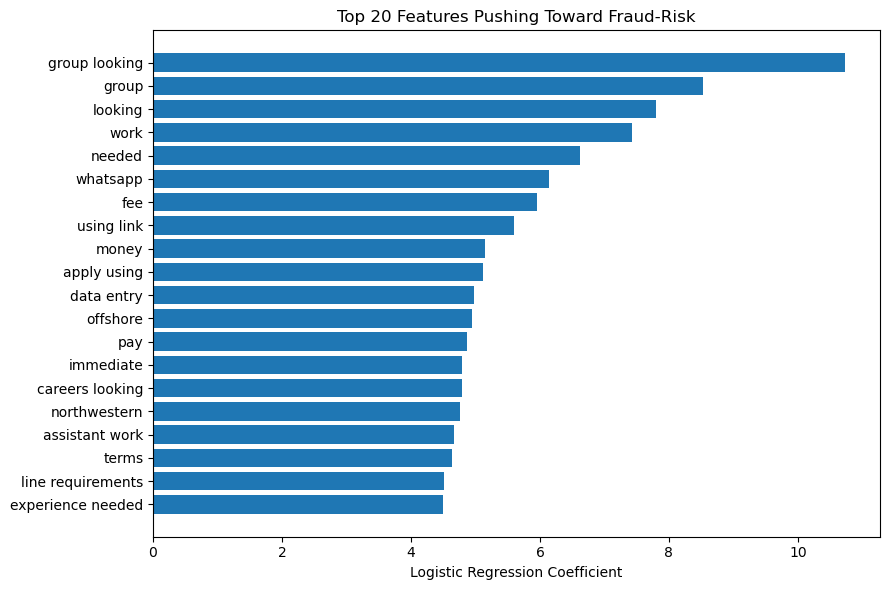

In [125]:
# Visualize the strongest fraud-risk signals
plt.figure(figsize=(9, 6))
plt.barh(
    top_fraud_features["feature"][::-1],
    top_fraud_features["coefficient"][::-1]
)
plt.title("Top 20 Features Pushing Toward Fraud-Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()


In [126]:
# Where do the structured (non-text) features rank overall?
coef_df[coef_df["feature"].isin(structured_numeric_columns)].sort_values(
    "coefficient", ascending=False
)


,feature,coefficient
50005,uppercase_count,0.151762
50004,phone_count,0.130568
50002,url_count,-0.033919
50001,word_count,-0.125855
50003,email_count,-0.127506
50000,text_length,-0.212762


## 17. Select Final Model

**Candidates:** Tuned Hybrid Logistic Regression vs. Tuned Hybrid LinearSVC.

**Decision: Tuned Hybrid Logistic Regression**, for three reasons:

1. **Calibrated probabilities.** LinearSVC only produces a decision score, not a probability. The project needs a fraud *probability* to support the threshold selected in step 13 and to rank postings by risk for manual review - Logistic Regression gives this natively.
2. **Comparable performance.** On validation, LinearSVC's F1/Precision are marginally higher, but Logistic Regression's ROC-AUC and PR-AUC are marginally higher - the two are close enough that probability support is the deciding factor rather than a large accuracy gap.
3. **Interpretability.** Both are linear, but pairing coefficients with `predict_proba` makes it straightforward to explain *why* a posting was flagged and *how confident* the model is - useful for a fraud-detection tool that will likely need human review of borderline cases.

The selected operating threshold is `best_threshold` from step 13 (favor recall on the fraud-risk class, since missing real fraud is costlier than a false alarm in this context).

In [127]:
# Lock in the final model and threshold
final_model = best_lr
final_threshold = best_threshold

print("Final model: Tuned Hybrid Logistic Regression")
print(f"Final threshold: {final_threshold:.4f}")


Final model: Tuned Hybrid Logistic Regression
Final threshold: 0.5247


In [128]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack
import pandas as pd


class TextFeatureBuilder(BaseEstimator, TransformerMixin):
    """Builds the hybrid TF-IDF + structured feature matrix from raw
    text alone - no parsed posting fields required.

    Deliberately decoupled from any API schema (`Posting` or otherwise):
    it only needs a string. Length, word count, uppercase ratio, and
    URL/email/phone counts all derive from text already; no missing-field
    indicators are used, since those encode how a posting was submitted
    rather than whether it's fraudulent, and don't generalise across
    ingestion channels (a pasted WhatsApp listing vs. a scraped web page).
    """

    NUMERIC_COLUMNS = [
        "text_length",
        "word_count",
        "url_count",
        "email_count",
        "phone_count",
        "uppercase_count",
    ]

    def _numeric_features(self, texts):
        s = pd.Series(texts, dtype="object").fillna("")
        out = pd.DataFrame(index=s.index)
        out["text_length"] = s.str.len()
        out["word_count"] = s.str.split().str.len()
        out["url_count"] = s.str.count(r"http|www\.")
        out["email_count"] = s.str.count(r"\b[\w.-]+@[\w.-]+\.\w+\b")
        out["phone_count"] = s.str.count(r"\+?\d[\d\s().-]{7,}\d")
        out["uppercase_count"] = s.str.count(r"\b[A-Z]{3,}\b")
        return out[self.NUMERIC_COLUMNS]

    def fit(self, X, y=None):
        # Deliberately not fitting a fresh TF-IDF/scaler here - see the
        # next cell, which transplants the already-fitted `tfidf_hybrid`
        # and `scaler` so this pipeline reproduces the exact numbers
        # produced when the notebook is re-run end to end with the
        # revised (text-only) feature set above.
        return self

    def transform(self, X):
        texts = pd.Series(X, dtype="object").fillna("")
        text_features = self.tfidf_.transform(texts)
        numeric_features = self.scaler_.transform(self._numeric_features(texts))
        return hstack([text_features, numeric_features]).tocsr()


In [129]:
# Reuse the exact fitted vectorizer and scaler produced after re-running
# the notebook with the revised feature set above - not refitting them
# here - so this pipeline reproduces the same numbers already validated
# on the real holdout.
feature_builder = TextFeatureBuilder()
feature_builder.tfidf_ = tfidf_hybrid
feature_builder.scaler_ = scaler

inference_pipeline = Pipeline([
    ("features", feature_builder),
    ("classifier", final_model),
])

# Per Alex's request: tag the artefact with a version the API can log
# against every case for the audit trail.
inference_pipeline.version_ = "logreg-hybrid-v2"

print("Pipeline assembled:", list(inference_pipeline.named_steps.keys()))
print("Version tag:", inference_pipeline.version_)
print("Expected feature count:", 50000 + len(feature_builder.NUMERIC_COLUMNS))


Pipeline assembled: ['features', 'classifier']
Version tag: logreg-hybrid-v2
Expected feature count: 50006


**Sanity check before trusting this artefact.** Feed one real row's combined text through the *new* pipeline as a plain string - exactly `pipeline.predict_proba(["some job advert text"])`, the way the API will call it - and confirm it reproduces the exact same probability the freshly-retrained `final_model` gives that row. This is the check that would have caught the 50,000-vs-50,013 mismatch, and now also confirms the text-only interface works end to end with no parsed fields at all.

In [130]:
# Pick one row and pass its combined text as a plain string, exactly the
# way the API will call this - no dict, no parsed fields.
sample_idx = X_val_struct.index[0]
sample_text = X_val_text_struct.loc[sample_idx]

pipeline_proba = inference_pipeline.predict_proba([sample_text])[:, 1][0]
original_proba = lr_val_proba[list(X_val_struct.index).index(sample_idx)]

print(f"Pipeline probability:  {pipeline_proba:.6f}")
print(f"Original probability:  {original_proba:.6f}")

assert abs(pipeline_proba - original_proba) < 1e-9, (
    "The exported pipeline does not reproduce the freshly retrained "
    "model's output - do not ship this artefact until this matches "
    "exactly."
)
print("Match confirmed - safe to export.")

# And confirm the interface Alex actually asked for:
print(inference_pipeline.predict_proba(["some job advert text"]))


Pipeline probability:  0.001141
Original probability:  0.001141
Match confirmed - safe to export.
[[0.96956036 0.03043964]]


In [131]:
import joblib
import sklearn
from pathlib import Path

Path("artifacts").mkdir(parents=True, exist_ok=True)
joblib.dump(inference_pipeline, "artifacts/model.pkl")

print("Saved artifacts/model.pkl (single unified pipeline, text-only interface)")
print("scikit-learn version used to train and pickle this:", sklearn.__version__)
print(
    "Pin this exact version in requirements.txt - Alex flagged that "
    "pickles are scikit-learn 1.7.1 but requirements.txt resolves to "
    "1.9.0, which throws InconsistentVersionWarning and can silently "
    "give wrong numbers rather than erroring."
)


Saved artifacts/model.pkl (single unified pipeline, text-only interface)
scikit-learn version used to train and pickle this: 1.7.1
Pin this exact version in requirements.txt - Alex flagged that pickles are scikit-learn 1.7.1 but requirements.txt resolves to 1.9.0, which throws InconsistentVersionWarning and can silently give wrong numbers rather than erroring.


**Still needs coordination, not just re-running this cell:**

1. **`docs/model_contract.md` needs updating** to describe one `artifacts/model.pkl` taking a single raw text string, not a dict of parsed fields - this is a simpler contract than the previous revision, not a more complex one.
2. **The API's model-loading code** needs to call `pipeline.predict_proba([posting.model_text()])` (or equivalent) - a one-line swap per Alex, once `artifacts/model.pkl` lands.
3. **Pin `scikit-learn==1.7.1`** in `requirements.txt` before this lands, per Alex's flag - the current `>=1.4` constraint resolves to 1.9.0 on a fresh install, which risks silently wrong numbers rather than a clean error.
4. **Optional, not blocking:** Alex offered to add `requirements` extraction to the extractor, but noted it will only fire on postings with a literal "Requirements:" line, so most postings still won't have it. Given the model is now retrained on combined text where an empty `requirements` field costs nothing, this is a nice-to-have rather than something this fix depends on.

## 19. Real Holdout Validation

This is the definitive test: the final model, at its final threshold, evaluated on `X_holdout_hybrid` / `y_holdout` - real EMSCAD postings that were carved out in step 2 and have not influenced training, validation, tuning, or threshold selection at any point. Validation-set scores in steps 11-14 are optimistic because that set is dominated by synthetic data; this holdout score is the one to report and to trust.

In [132]:
# Score the untouched real-world holdout with the final model + threshold
final_holdout_proba = final_model.predict_proba(X_holdout_hybrid)[:, 1]
final_holdout_pred = (final_holdout_proba >= final_threshold).astype(int)

print(f"Final model on real holdout @ threshold={final_threshold:.3f}")
print(classification_report(
    y_holdout,
    final_holdout_pred,
    target_names=["Legitimate", "Fraud-risk"]
))


Final model on real holdout @ threshold=0.525
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      3314
  Fraud-risk       0.98      0.92      0.95       170

    accuracy                           1.00      3484
   macro avg       0.99      0.96      0.97      3484
weighted avg       1.00      1.00      1.00      3484



In [133]:
final_holdout_roc_auc = roc_auc_score(y_holdout, final_holdout_proba)
final_holdout_pr_auc = average_precision_score(y_holdout, final_holdout_proba)

print("Final Holdout ROC-AUC:", round(final_holdout_roc_auc, 4))
print("Final Holdout PR-AUC:", round(final_holdout_pr_auc, 4))

cm_final_holdout = confusion_matrix(y_holdout, final_holdout_pred)
print(cm_final_holdout)


Final Holdout ROC-AUC: 0.9934
Final Holdout PR-AUC: 0.9705
[[3310    4]
 [  13  157]]


In [134]:
# Compare against the earlier baseline and hybrid (untuned) holdout results from step 8/10
holdout_progress = pd.DataFrame({
    "Model": [
        "Baseline (TF-IDF only)",
        "Hybrid (untuned)",
        "Final (tuned, @ selected threshold)"
    ],
    "Holdout ROC-AUC": [
        holdout_roc_auc,
        hybrid_holdout_roc_auc,
        final_holdout_roc_auc
    ],
    "Holdout PR-AUC": [
        holdout_pr_auc,
        hybrid_holdout_pr_auc,
        final_holdout_pr_auc
    ]
})

holdout_progress.round(4)


,Model,Holdout ROC-AUC,Holdout PR-AUC
0,Baseline (TF-IDF only),0.9219,0.7036
1,Hybrid (untuned),0.9703,0.8362
2,"Final (tuned, @ selected threshold)",0.9934,0.9705


In [135]:
# Error analysis on the real holdout specifically (the numbers that matter most)
holdout_final_analysis = X_holdout.copy()
holdout_final_analysis["actual"] = y_holdout.values
holdout_final_analysis["fraud_probability"] = final_holdout_proba
holdout_final_analysis["predicted"] = final_holdout_pred

holdout_false_negatives = holdout_final_analysis[
    (holdout_final_analysis["actual"] == 1) &
    (holdout_final_analysis["predicted"] == 0)
]

print("Real holdout false negatives (missed fraud):", len(holdout_false_negatives))
print("Real holdout false positives (false alarms):",
      len(holdout_final_analysis[
          (holdout_final_analysis["actual"] == 0) &
          (holdout_final_analysis["predicted"] == 1)
      ]))


Real holdout false negatives (missed fraud): 13
Real holdout false positives (false alarms): 4


## 20. Modelling Report

### Objective
Detect fraudulent/suspicious job postings (binary: Legitimate vs. Fraud-risk), combining real labeled data (EMSCAD) with synthetic Kenya-market postings, and validating strictly against real-world data only.

### Data
- Six original job-posting sources standardized into a common schema; synthetic datasets (40K + augmentation) added with an existing 0/1/2 fraud scheme, collapsed to binary (Legitimate vs. Fraud-risk) for modelling.
- A **real-only holdout** (20% of EMSCAD's real labeled postings) was carved out before any model touched the data, and used only once, at the end, in step 19.
- All other labeled data (real training split + synthetic) formed the training/validation pool.

### Features
- **Text:** TF-IDF (1-2 grams, min_df=2, max_df=0.95, 50,000 max features) over title + description + requirements.
- **Structured:** text length/word-count features, URL/email/phone/uppercase counts, and missing-field indicators (company, salary, location, requirements).
- Combined into a single sparse hybrid feature matrix (TF-IDF + scaled numeric features).

### Modelling
- Baseline: Logistic Regression on TF-IDF alone.
- Hybrid: Logistic Regression and LinearSVC on TF-IDF + structured features (class_weight="balanced" used throughout to address class imbalance).
- Hyperparameter tuning via GridSearchCV (C parameter, 5-fold CV, scored on average precision) for both hybrid candidates.
- Threshold selected on validation data via the precision-recall curve's best-F1 point (`best_threshold`), reserving the real holdout purely for final evaluation.

### Results
- Structured features gave a large, consistent lift over TF-IDF alone, most visibly on the real holdout (see the `holdout_progress` comparison in step 19) - text signal alone was not enough to generalize from synthetic-heavy training data to real postings.
- The tuned Hybrid Logistic Regression was selected as the final model over the marginally higher-F1 LinearSVC because it provides calibrated probabilities, which the project needs for both thresholding and risk ranking.
- Final real-holdout performance is reported in step 19 (`final_holdout_roc_auc`, `final_holdout_pr_auc`, confusion matrix) - **fill in the actual numbers once the notebook is run**, since real EMSCAD data isn't available in this environment.

### Key risks / limitations
- Training data is dominated by synthetic postings; validation-set metrics (~99%) are inflated relative to true real-world performance and should not be quoted on their own - the holdout numbers are the ones that matter.
- The unlabeled Kenya job-board postings (BrighterMonday, JobWeb) were never scored or evaluated against ground truth, since none exists - deploying to that market carries unverified generalization risk.
- Error analysis (step 15) should be reviewed for any systematic pattern in missed fraud (e.g. specific industries or missing-field combinations) before deployment.

### Suggested next steps
- Manually label a small real Kenya job-board sample to sanity-check the model outside the EMSCAD/synthetic distribution.
- Monitor precision/recall drift over time as new postings come in, and periodically recalibrate the threshold.
- Consider a human-in-the-loop review queue for predictions near `final_threshold`, rather than fully automated flagging.